# thalamus: spindle3 for c2tsc

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
#sys.path.append(os.path.join(now_dir, r'models\spindle_00'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


In [15]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
params = dp.loadDefaultParams(0)
#params["p3"] = 82.0
#params["p3"] = 1 
#params["c2tsc"] = 0.8
params["duration"] = 30
#params["tau_ou"] = 42.0
#params["mui_ext_mean"] = 3.0
#params["cee"] = 3.0
#params["tau_se"] = 0.2
#params["Jtr"] = 3.42 /2.5
#params["scale2"] = 0.0013
#params["tau_ou"] = 10.0
#params['p4'] = 1
#params["dt"] = 0.0001
#params["cie"] = 0.3
params["V_t_init"] = 1000
params["V_r_init"] = 1000
'''
params["Jet"] = 78.2 #18 * 0.8 #1.98
params["Jer"] = 162 #0.23 * 0.8 #3.24
params["c2tsc"] = 0.8 #0.8
params["scale2"] = 0.0005 #0.0013
'''

a = 8.4 #9.5
params["VT_t"] = 26 -a#26 -9
params["VT_r"] = 23 -a#23
params["VB_t"] = 15 -a#15
params["VB_r"] = 15 -a#15

#params["Jrt"] = -0.6 #-1.5 # -0.5
#params

In [16]:
params

{'dt': 0.0001,
 'duration': 30,
 'model': 'spindle3',
 'seed': 0,
 'c2tsc': 0,
 'scale2': 0,
 'p1': 1.0,
 'p2': 0.008,
 'p3': 1.0,
 'p4': 1.0,
 'tau_t': 0.044,
 'tau_r': 0.022,
 'f_t_max': 250,
 'f_r_max': 200,
 'f_t_th': 50,
 'f_r_th': 110,
 'gamma_t': 0.008,
 'gamma_r': 0.008,
 'At': 0.0034375,
 'Ar': 0.00171875,
 'tau_u_t': 0.22,
 'tau_u_r': 0.11,
 'RT_t': 100,
 'RT_r': 180,
 'RB_t': 250,
 'RB_r': 250,
 'VT_t': 17.6,
 'VT_r': 14.6,
 'VB_t': 6.6,
 'VB_r': 6.6,
 'gT_t': 6,
 'gT_r': 3,
 'gB_t': 0.9,
 'gB_r': 0.6,
 'Lt': 0.04,
 'Lr': 0.04,
 'Nt': 500.0,
 'Nr': 500.0,
 'Prr': 0.02,
 'Ptr': 0.01,
 'Prt': 0.04,
 'Jrr': -0.09,
 'Jtr': 3.42,
 'Jrt': -0.5,
 'tau_e': 0.02,
 'tau_i': 0.01,
 'tau_c': 0.5,
 'Ne': 8000.0,
 'Ni': 2000.0,
 'delta_c': 0.005,
 'delta_c2': 0.0054,
 'ge': 5,
 'gi': 2,
 'Rm': 70,
 'V_star': 30,
 'c_star': 10,
 'gc': 3,
 'Pee': 0.2,
 'Pe2e': 0.01,
 'Pee2': 0.01,
 'Pie': 0.2,
 'Pte': 0.02,
 'Pii': 0.2,
 'Pei': 0.2,
 'Pe2i': 0.01,
 'Pei2': 0.01,
 'Pti': 0.02,
 'Pet': 0.01,


### 普通的单次运行

In [17]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


#### chirp

In [18]:
import numpy as np
import pandas as pd
import yasa
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
from scipy.fft import fft, fftfreq


# ========== 1. Basic setup ==========
duration = params["duration"]
sf = float(1.0 / (t[1] - t[0])) * 10000
print(f"Sampling rate: {sf} Hz")
print(f"Duration: {duration} s")


# ========== 2. Filter function using neurolib Signal ==========
def get_phase_and_filtered(signal, filter_args, pad=None):
    """Filter a Signal object and return (phase, filtered signal)."""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values, filtered


def filter_signal_neurolib(data, sf, low_freq, high_freq, pad_seconds=None):
    """
    Filter a 1-D numpy array using neurolib's Signal class.

    Parameters
    ----------
    data : np.ndarray
        Input signal (1-D).
    sf : float
        Sampling rate in Hz.
    low_freq, high_freq : float
        Band-pass filter edges in Hz.
    pad_seconds : float or None
        Padding duration (seconds) on both sides. If None, no padding.

    Returns
    -------
    filtered : np.ndarray
        Band-pass filtered signal (same length as input if pad=None).
    """
    # Build a time axis in seconds
    time_sec = np.arange(len(data)) / sf
    xr_data = xr.DataArray(data, dims=["time"], coords={"time": time_sec})
    sig = RatesSignal(xr_data)

    filter_args = {"low_freq": low_freq, "high_freq": high_freq}

    # Use pad=0.0 if pad_seconds is None (no padding)
    pad_val = 0.0 if pad_seconds is None else pad_seconds

    _, filtered = get_phase_and_filtered(sig, filter_args=filter_args, pad=pad_val)
    return filtered


# ========== 3. Chirp calculation function ==========
def compute_chirp_wft(signal, sf, freq_band=(8, 16), n_steps=13,
                       window_sec=0.5, n_fft=2**16):
    """
    Compute chirp rate (Hz/s) using windowed FFT on a neurolib-filtered signal.

    Steps:
    1. Filter the signal with neurolib (pad 0.5 s each side).
    2. Slide a short Gaussian-weighted window across the filtered signal.
    3. For each window, find the peak frequency via zero-padded FFT.
    4. Fit a line to peak frequency vs time -> slope = chirp rate (Hz/s).

    Parameters
    ----------
    signal : np.ndarray
        Raw spindle segment (1-D).
    sf : float
        Sampling rate in Hz.
    freq_band : tuple
        (low, high) frequency band in Hz for filtering and peak search.
    n_steps : int
        Number of sliding windows.
    window_sec : float
        Length of each sliding window (seconds).
    n_fft : int
        FFT length for zero-padding (finer frequency resolution).

    Returns
    -------
    chirp_rate : float
        Slope of peak frequency vs time (Hz/s). NaN if it fails.
    """
    try:
        # 1. Filter with neurolib (pad 0.5 s on both sides)
        filtered = filter_signal_neurolib(
            signal, sf,
            low_freq=freq_band[0],
            high_freq=freq_band[1],
            pad_seconds=0.5,
        )

        # 2. Sliding window
        window_samples = int(window_sec * sf)
        if len(filtered) < window_samples:
            return np.nan

        step_samples = max(1, (len(filtered) - window_samples) // (n_steps - 1))

        peak_freqs = []
        times = []

        for i in range(n_steps):
            start = i * step_samples
            end = start + window_samples
            if end > len(filtered):
                break
            segment = filtered[start:end]

            # Gaussian weighting (center at middle of window)
            gaussian = np.exp(
                -0.5 * ((np.arange(len(segment)) - len(segment) / 2) / (len(segment) / 6)) ** 2
            )
            weighted = segment * gaussian

            # FFT with zero-padding
            spectrum = np.abs(fft(weighted, n=n_fft))
            freqs = fftfreq(n_fft, 1 / sf)

            # Keep only positive frequencies within the band
            mask = (freqs > freq_band[0]) & (freqs < freq_band[1])
            freqs_pos = freqs[mask]
            spectrum_pos = spectrum[mask]

            if len(spectrum_pos) == 0:
                continue

            # Parabolic interpolation for sub-bin precision
            peak_idx = int(np.argmax(spectrum_pos))
            if 0 < peak_idx < len(spectrum_pos) - 1:
                y1 = spectrum_pos[peak_idx - 1]
                y2 = spectrum_pos[peak_idx]
                y3 = spectrum_pos[peak_idx + 1]
                denom = (y1 - 2 * y2 + y3)
                if denom != 0:
                    delta = 0.5 * (y1 - y3) / denom
                else:
                    delta = 0.0
                df = freqs_pos[1] - freqs_pos[0]
                peak_freq = freqs_pos[peak_idx] + delta * df
            else:
                peak_freq = freqs_pos[peak_idx]

            peak_freqs.append(peak_freq)
            times.append((start + end) / 2 / sf)

        if len(peak_freqs) < 3:
            return np.nan

        # 3. Linear fit -> slope = chirp rate
        chirp_rate = np.polyfit(times, peak_freqs, 1)[0]
        return chirp_rate

    except Exception as e:
        print(f"  [chirp error] {e}")
        return np.nan


# ========== 4. Spindle detection (same as your code) ==========
sp2 = yasa.spindles_detect(
    V_t, sf, min_distance=200, freq_sp=(12, 16), duration=(0.3, 2),
    thresh={"rel_pow": 0.20, "corr": 0.65, "rms": 1.5},
)
print("Fast spindles (12-16 Hz):", len(sp2.summary()) if sp2 else 0)

sp4 = yasa.spindles_detect(
    V_t, sf, min_distance=200, freq_sp=(8, 12), duration=(0.3, 2),
    thresh={"rel_pow": 0.20, "corr": 0.65, "rms": 1.5},
)
print("Slow spindles (8-12 Hz):", len(sp4.summary()) if sp4 else 0)


# ========== 5. Analyze chirp for each spindle ==========
def analyze_chirp(sp, V_t, sf, freq_band, label):
    """Compute chirp for every spindle detected by YASA."""
    if sp is None:
        print(f"\n=== {label}: no spindles detected ===")
        return None

    summary = sp.summary()
    chirp_list = []

    print(f"\n=== {label} chirp analysis ===")

    for idx, row in summary.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]

        # Extract segment with 0.5 s padding on both sides
        pad = int(0.5 * sf)
        start_idx = max(0, int(start_time * sf) - pad)
        end_idx = min(len(V_t), int(end_time * sf) + pad)
        segment = V_t[start_idx:end_idx]

        # Compute chirp
        chirp = compute_chirp_wft(
            segment, sf, freq_band=freq_band,
            n_steps=13, window_sec=0.5,
        )
        chirp_list.append(chirp)

        print(f"  Spindle {idx+1}: start={start_time:.3f}s, "
              f"peak={peak_time:.3f}s, end={end_time:.3f}s, "
              f"chirp = {chirp:+.3f} Hz/s")

    # Summary
    chirp_array = np.array(chirp_list)
    valid = chirp_array[~np.isnan(chirp_array)]

    if len(valid) == 0:
        print(f"  No valid chirp values for {label}")
        return None

    mean_chirp = np.mean(valid)
    std_chirp = np.std(valid)

    n_neg = int(np.sum(valid < 0))
    n_pos = int(np.sum(valid > 0))
    n_zero = int(np.sum(valid == 0))

    print(f"\n  --- {label} summary ---")
    print(f"  Mean chirp: {mean_chirp:+.3f} +/- {std_chirp:.3f} Hz/s (n={len(valid)})")
    print(f"  Negative chirp: {n_neg}/{len(valid)} ({100*n_neg/len(valid):.1f}%)")
    print(f"  Positive chirp: {n_pos}/{len(valid)} ({100*n_pos/len(valid):.1f}%)")
    print(f"  Zero chirp:     {n_zero}/{len(valid)} ({100*n_zero/len(valid):.1f}%)")

    return {
        "chirp_array": chirp_array,
        "mean": mean_chirp,
        "std": std_chirp,
        "n_neg": n_neg,
        "n_pos": n_pos,
        "n_zero": n_zero,
        "n_valid": len(valid),
    }


fast_result = analyze_chirp(sp2, V_t, sf, freq_band=(12, 16), label="Fast spindles (12-16 Hz)")
slow_result = analyze_chirp(sp4, V_t, sf, freq_band=(8, 12), label="Slow spindles (8-12 Hz)")


# ========== 6. Comparison ==========
print("\n" + "=" * 60)
print("Comparison: Fast vs Slow")
print("=" * 60)

if fast_result and slow_result:
    print(f"Fast spindle mean chirp: {fast_result['mean']:+.3f} Hz/s")
    print(f"Slow spindle mean chirp: {slow_result['mean']:+.3f} Hz/s")
    print(f"Difference: {fast_result['mean'] - slow_result['mean']:+.3f} Hz/s")

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
24-Sep-26 16:40:47 | WARNING | No spindle were found in channel CHAN000.
24-Sep-26 16:40:47 | WARNING | No spindles were found in data. Returning None.


Sampling rate: 10000.0 Hz
Duration: 30 s
Fast spindles (12-16 Hz): 0


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Slow spindles (8-12 Hz): 1

=== Fast spindles (12-16 Hz): no spindles detected ===

=== Slow spindles (8-12 Hz) chirp analysis ===
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


  Spindle 1: start=25.744s, peak=25.906s, end=26.153s, chirp = +0.463 Hz/s

  --- Slow spindles (8-12 Hz) summary ---
  Mean chirp: +0.463 +/- 0.000 Hz/s (n=1)
  Negative chirp: 0/1 (0.0%)
  Positive chirp: 1/1 (100.0%)
  Zero chirp:     0/1 (0.0%)

Comparison: Fast vs Slow


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [19]:
print("Q_e", Q_e.max()*1000, Q_e.min()*1000)
print("Q_i", Q_i.max()*1000, Q_i.min()*1000)
print("V_e", V_e.max(), V_e.min())
print("Q_t", Q_t.max(), Q_t.min())
print("Q_r", Q_r.max(), Q_r.min())
print("V_t", V_t.max(), V_t.min())
print("V_r", V_r.max(), V_r.min())

Q_e 88.01771014995875 0.0
Q_i 85.94641887110497 0.0
V_e 1.0 -73.14731014592746
Q_t 226.0114678419567 0.0
Q_r 179.99990224012603 0.0
V_t 1000.0 -17.115713794013562
V_r 1000.0 0.29283561226659155


[ 0.          1.42857143  2.85714286  4.28571429  5.71428571  7.14285714
  8.57142857 10.         11.42857143 12.85714286]


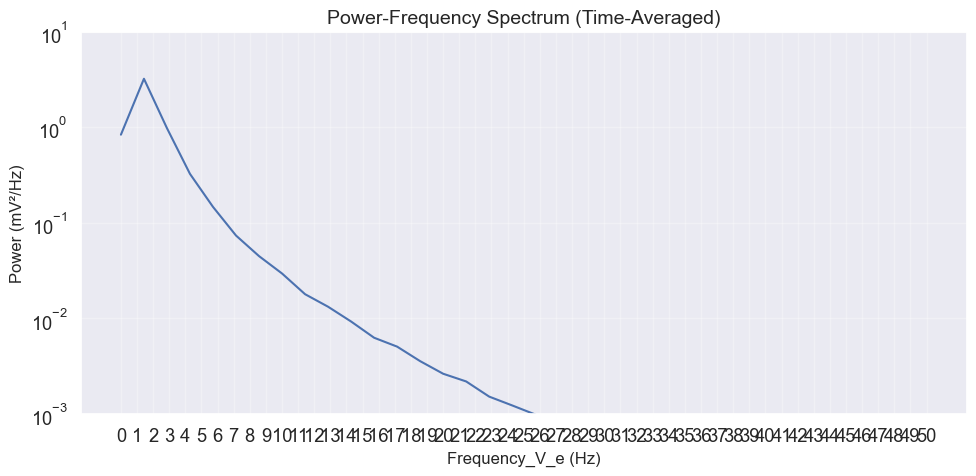

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ========== 参数设置 ==========
fs = 1 / 0.0001              # 采样率 (Hz)   <--- 改成你自己的
duration = 10           # 信号时长 (秒) <--- 改成你自己的
freq_range = (0, 50)  # 要显示的频率范围 (Hz)
#freq_range = (0, 4.5)  # 要显示的频率范围 (Hz)

# ========== 计算功率谱 (Welch 方法) ==========
# Welch 方法自动做平均，得到长时间平均的功率谱
#f, Pxx = signal.welch(V_t, fs, nperseg=fs*3, scaling='density')
param = "V_e"
f, Pxx = signal.welch(eval(param), fs, nperseg=fs*0.7, scaling='density') #'density')
print(f[:10])  # 打印前10个频率值
# ========== 绘图 ==========
plt.figure(figsize=(10, 5))
# 只显示感兴趣的频率范围
mask = (f >= freq_range[0]) & (f <= freq_range[1])
plt.semilogy(f[mask], Pxx[mask], linewidth=1.5)
#plt.ylim([0.25, 15]) 
plt.ylim([0.001, 10]) 
plt.xticks(np.arange(freq_range[0], freq_range[1] + 1, 1)) 
plt.xlabel(f'Frequency_{param} (Hz)', fontsize=12)
plt.ylabel('Power (mV²/Hz)', fontsize=12)
plt.title('Power-Frequency Spectrum (Time-Averaged)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

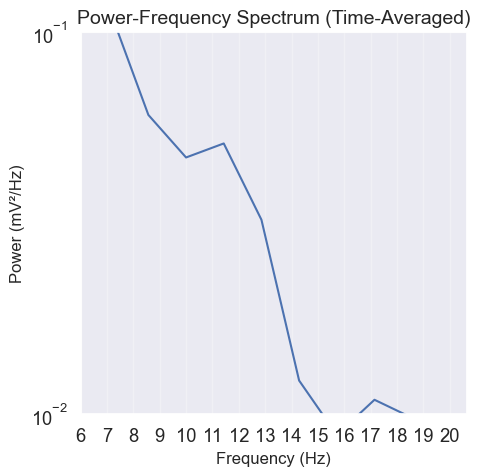

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import matplotlib.ticker as ticker

# ========== 参数设置 ==========
fs = 1 / 0.0001              # 采样率 (Hz)
duration = 10                # 信号时长 (秒)
freq_range = (6, 20)         # 要显示的频率范围 (Hz)

# ========== 计算功率谱 (Welch 方法) ==========
f, Pxx = signal.welch(V_t, fs, nperseg=fs*0.7, scaling='density')

# ========== 绘图 ==========
plt.figure(figsize=(5, 5))

mask = (f >= freq_range[0]) & (f <= freq_range[1])
plt.semilogy(f[mask], Pxx[mask], linewidth=1.5)

plt.ylim([0.01, 1e-1])

# ========== 强制只显示指定的纵轴刻度 ==========
# 方法1：只保留主要刻度，移除次要刻度
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.FixedLocator([0.01, 0.1]))
ax.yaxis.set_minor_locator(ticker.NullLocator())  # 移除次要刻度

# 方法2：如果不想要任何刻度，用这个
# ax.yaxis.set_major_locator(ticker.NullLocator())

# ========== 设置横轴刻度 ==========
plt.xticks(np.arange(freq_range[0], freq_range[1] + 1, 1))

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power (mV²/Hz)', fontsize=12)
plt.title('Power-Frequency Spectrum (Time-Averaged)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:

import yasa
import xarray as xr
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
'''
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)
'''
sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.20, "corr":0.65, "rms":1.5})
print("TCR:",sp2.summary()["Frequency"]) if sp2 else  print("NO Fast spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate2 = len(sp2._events) / duration if sp2 else 0
print("Fast spindles:", rate2)

sp4 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,12), duration=(0.3,2), thresh={"rel_pow":0.20, "corr":0.65, "rms":1.5})
print("TCR:",sp4.summary()["Frequency"]) if sp4 else  print("NO Slow spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate4 = len(sp4._events) / duration if sp4 else 0
print("Slow spindles:", rate4)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
24-Sep-26 16:40:48 | WARNING | No spindle were found in channel CHAN000.
24-Sep-26 16:40:48 | WARNING | No spindles were found in data. Returning None.


10000.0
NO Fast spindle in TCR
Fast spindles: 0


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


TCR: 0    9.364393
Name: Frequency, dtype: float64
Slow spindles: 0.03333333333333333


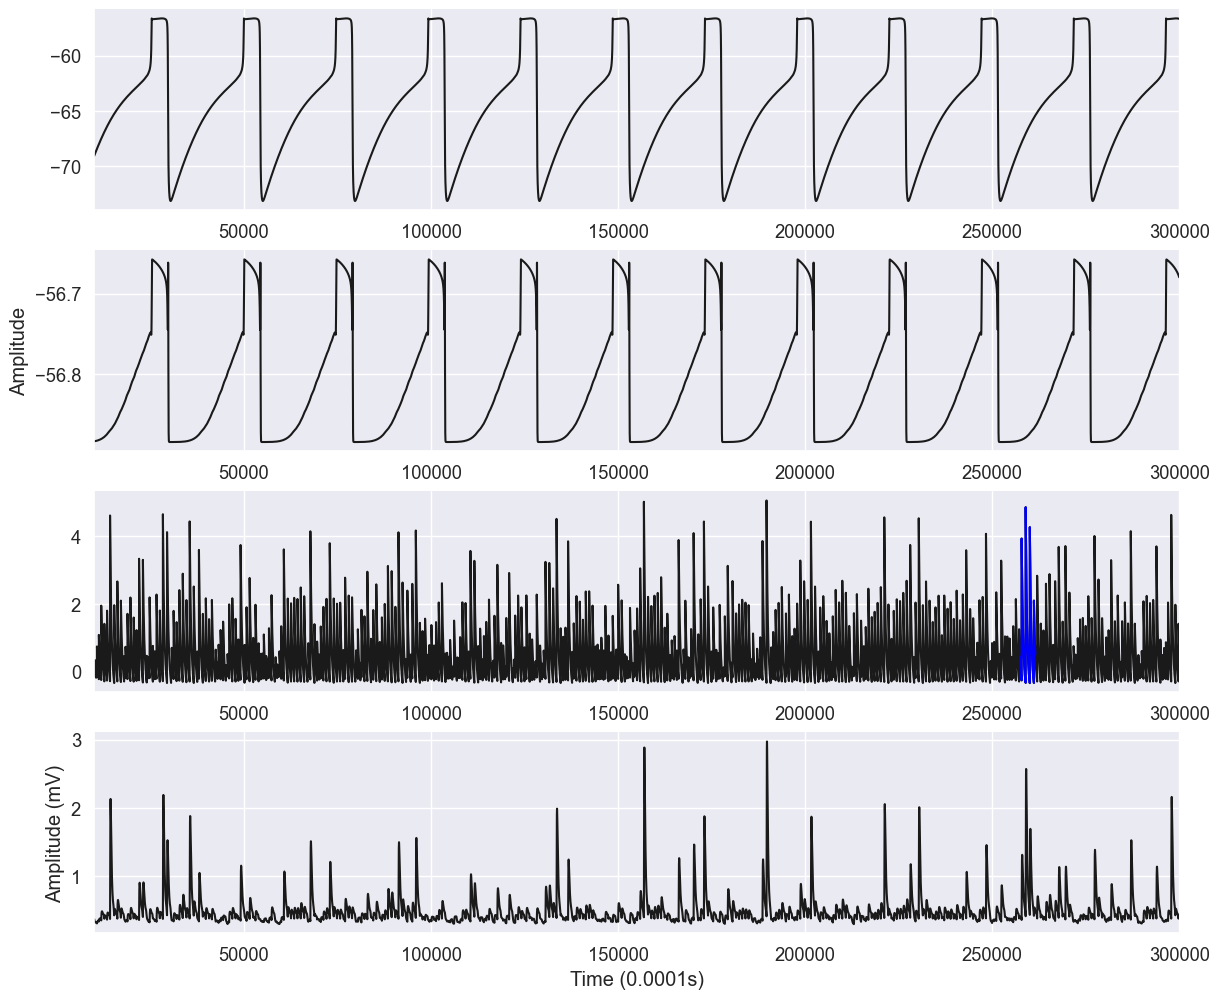

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(4, 1, figsize=(14, 12))

#plt.title('N2 sleep EEG data (2 spindles)')

plt.setp(ax, xlim=(t[10000:].min(), t[10000:].max()))
#plt.setp(ax, xlim=(t[100000:120000].min(), t[100000:120000].max()))
#plt.setp(ax, xlim = (t.min(), t.max()))
#plt.xlim([t[10000:].min()/10000, t[10000:].max()/10000])

plt.subplot(4,1,1)
plt.plot(t[10000:], V_e[10000:], lw=1.5, color='k')
#plt.plot(t[10000:], Q_e[10000:]*1000, lw=1.5, color='k')
'''
if sp1:
    mask1 = sp1.get_mask()
    spindles_highlight_e = Q_e * mask1
    spindles_highlight_e[spindles_highlight_e == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight_e[10000:]*1000, 'indianred')
'''
plt.subplot(4,1,2)
plt.plot(t[10000:], V_i[10000:], lw=1.5, color='k')
#plt.plot(t, Q_i*1000, lw=1.5, color='k')
plt.ylabel('Amplitude')


plt.subplot(4,1,3)
#plt.plot(t, V_t, lw=1.5, color='k')
plt.plot(t[10000:], V_t[10000:], lw=1.5, color='k')

if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'indianred')

if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = V_t * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'blue')



plt.subplot(4,1,4)
#plt.plot(t, V_r, lw=1.5, color='k')
plt.plot(t[10000:], V_r[10000:], lw=1.5, color='k')
plt.xlabel('Time (0.0001s)')
plt.ylabel('Amplitude (mV)')


sns.despine()

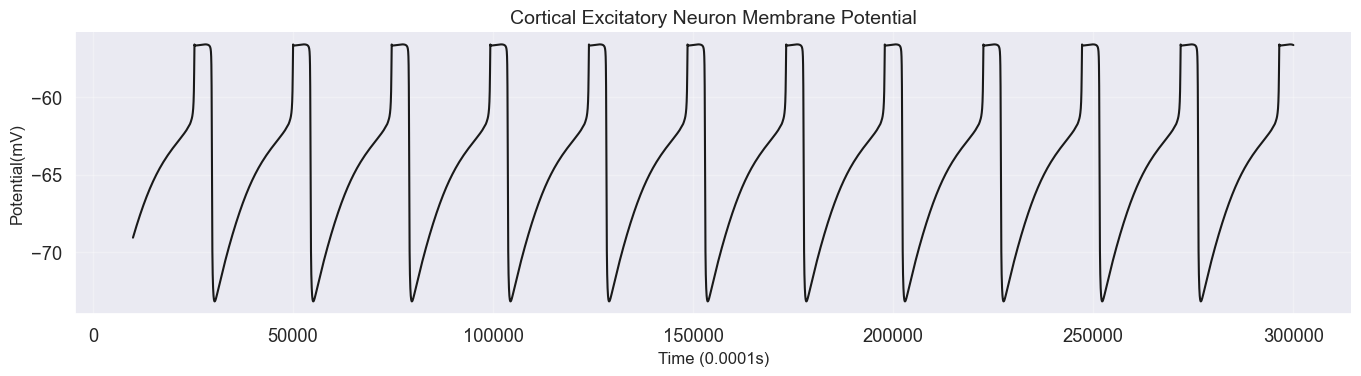

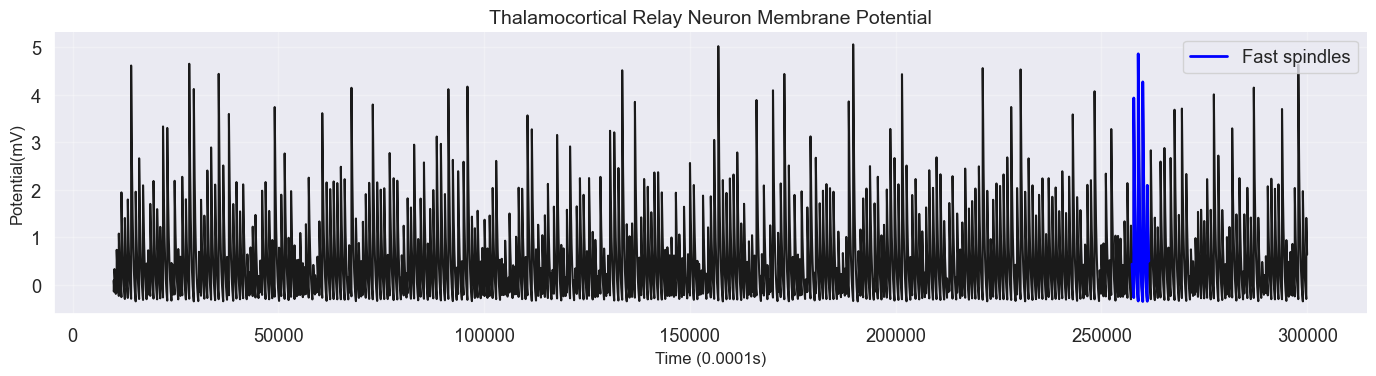

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

# ========== 图1：皮层兴奋性神经元 (V_e) ==========
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t[10000:], V_e[10000:], lw=1.5, color='k')
ax.set_xlabel('Time (0.0001s)', fontsize=12)
ax.set_ylabel('Potential(mV)', fontsize=12)
ax.set_title('Cortical Excitatory Neuron Membrane Potential', fontsize=14)
ax.grid(True, alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

# ========== 图2：丘脑皮层中继神经元 (V_t) ==========
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t[10000:], V_t[10000:], lw=1.5, color='k')

# 如果存在 sp2 检测结果，叠加显示纺锤波高亮
if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    ax.plot(t[10000:], spindles_highlight[10000:], 'indianred', lw=2, label='Slow spindles')

if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = V_t * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    ax.plot(t[10000:], spindles_highlight[10000:], 'blue', lw=2, label='Fast spindles')

ax.set_xlabel('Time (0.0001s)', fontsize=12)
ax.set_ylabel('Potential(mV)', fontsize=12)
ax.set_title('Thalamocortical Relay Neuron Membrane Potential', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

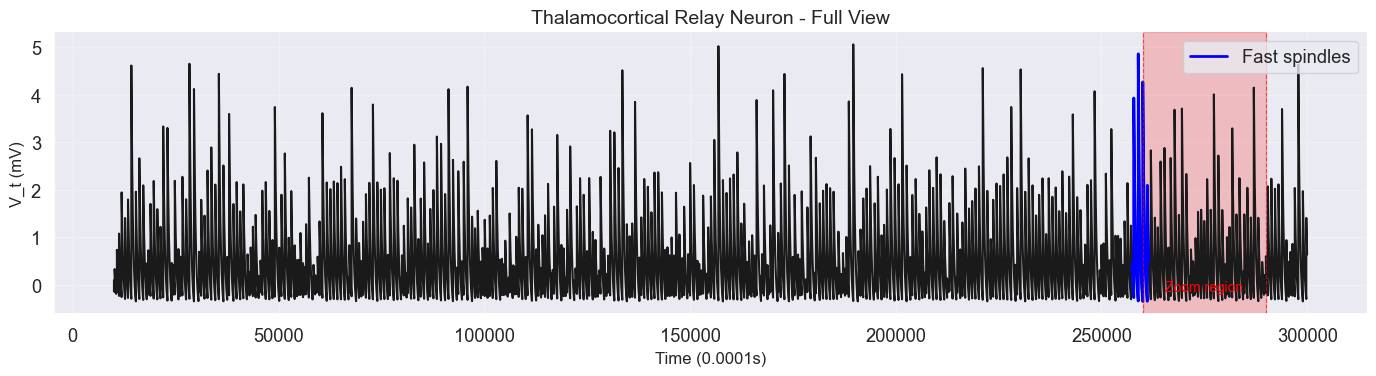

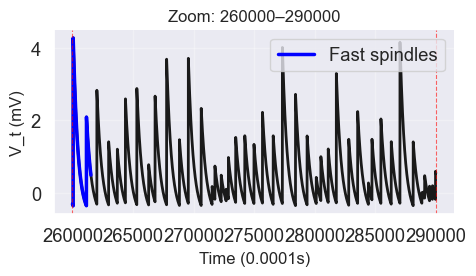

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(font_scale=1.2)

# ========== 自定义放大区间（单位：采样点索引）==========
zoom_start = 260000   # 起始索引
zoom_end = 290000     # 结束索引

# ========== 图1：主图（完整时间序列）==========
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t[10000:], V_t[10000:], lw=1.5, color='k')

if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    ax.plot(t[10000:], spindles_highlight[10000:], 'indianred', lw=2, label='Slow spindles')

if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = V_t * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    ax.plot(t[10000:], spindles_highlight[10000:], 'blue', lw=2, label='Fast spindles')

# 标记放大区间
ax.axvspan(zoom_start, zoom_end, alpha=0.2, color='red')
ax.axvline(x=zoom_start, color='red', linestyle='--', lw=0.8, alpha=0.6)
ax.axvline(x=zoom_end, color='red', linestyle='--', lw=0.8, alpha=0.6)
ax.text((zoom_start + zoom_end) / 2, ax.get_ylim()[0] + 0.08 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
        'Zoom region', ha='center', fontsize=10, color='red')

ax.set_xlabel('Time (0.0001s)', fontsize=12)
ax.set_ylabel('V_t (mV)', fontsize=12)
ax.set_title('Thalamocortical Relay Neuron - Full View', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

# ========== 图2：放大图（选定区间）==========
fig, ax = plt.subplots(figsize=(5, 3))

t_zoom = t[zoom_start:zoom_end]
V_t_zoom = V_t[zoom_start:zoom_end]

ax.plot(t_zoom, V_t_zoom, lw=2, color='k')

if sp2:
    mask2_zoom = sp2.get_mask()[zoom_start:zoom_end]
    spindles_highlight_zoom = V_t_zoom * mask2_zoom
    spindles_highlight_zoom[spindles_highlight_zoom == 0] = np.nan
    ax.plot(t_zoom, spindles_highlight_zoom, 'indianred', lw=2.5, label='Slow spindles')

if sp4:
    mask4_zoom = sp4.get_mask()[zoom_start:zoom_end]
    spindles_highlight_zoom = V_t_zoom * mask4_zoom
    spindles_highlight_zoom[spindles_highlight_zoom == 0] = np.nan
    ax.plot(t_zoom, spindles_highlight_zoom, 'blue', lw=2.5, label='Fast spindles')

ax.axvline(x=t[zoom_start], color='red', linestyle='--', lw=0.8, alpha=0.6)
ax.axvline(x=t[zoom_end], color='red', linestyle='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Time (0.0001s)', fontsize=12)
ax.set_ylabel('V_t (mV)', fontsize=12)
ax.set_title(f'Zoom: {zoom_start}–{zoom_end}', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

Setting up band-pass filter from 0.5 - 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 66001 samples (6.600 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


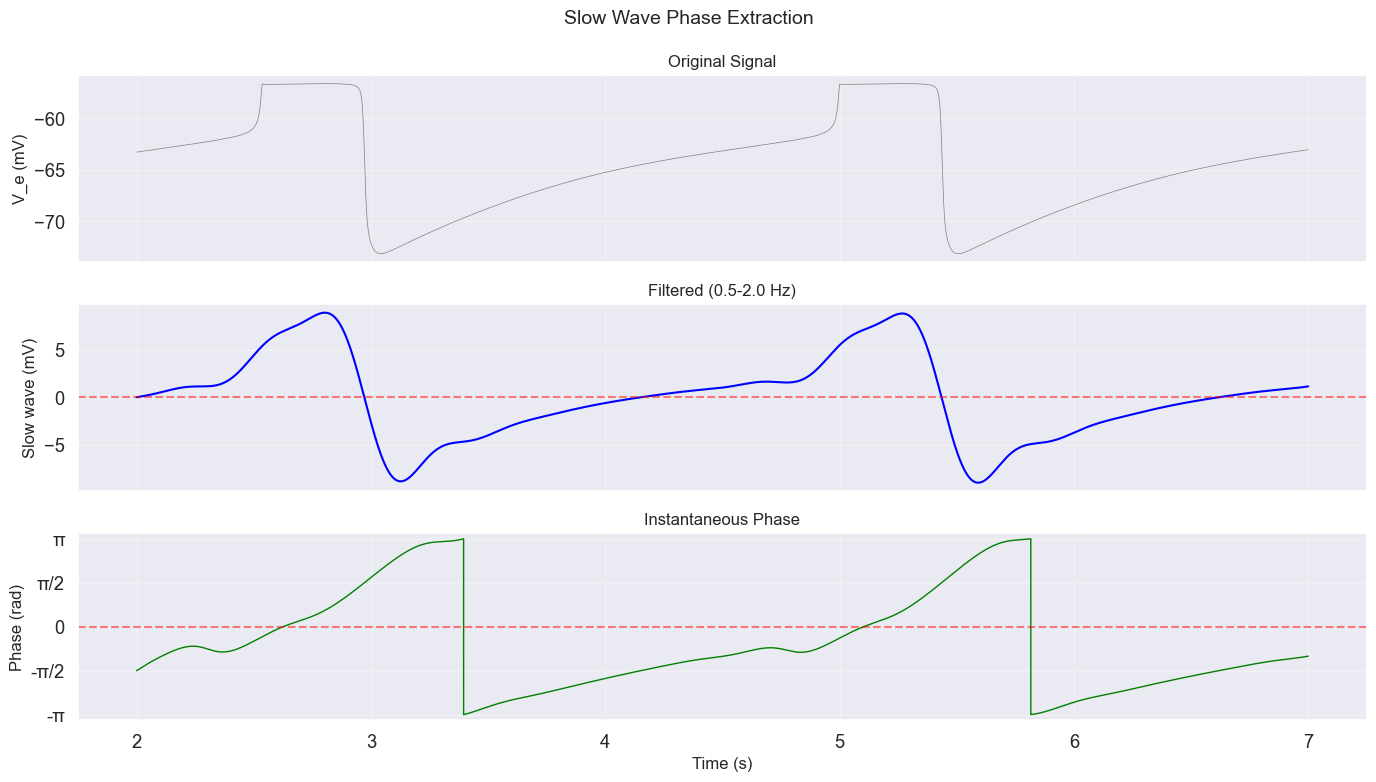

Phase shape: (260001,)
Phase range: [-3.142, 3.142] rad
Phase mean: -0.737 rad
Phase has NaN: False


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
from scipy.signal import hilbert
from scipy.stats import circmean, circstd

# ========== 参数设置 ==========
sf = 10000  # 采样率 (Hz)
SW = {"low_freq": 0.5, "high_freq": 2.0}  # 慢波滤波范围，可改成 {"low_freq": None, "high_freq": 3.0}
remove_edges_samples = 20000  # 去掉前后各 2 秒

# ========== 加载你的新数据 ==========
# 方法1：如果是 npy 文件
# data = np.load("你的文件路径.npy", allow_pickle=True).item()
# t = data["t"]
# V_e = data["V_e"]  # 或者 V_t

# 方法2：如果直接在变量里
# t = your_t
# V_e = your_V_e

# ========== 用 neurolib 方法提取相位 ==========
def get_phase_and_filtered(signal, filter_args, pad=None):
    """返回相位和滤波后的信号（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values, filtered

# 只取中间部分（去掉边界）
t_min = remove_edges_samples
t_max = t[-1] - remove_edges_samples
mask = (t >= t_min) & (t <= t_max)
t_mid = t[mask]
V_e_mid = V_e[mask]

# 构建 neurolib Signal 对象
time_sec = t_mid / sf
xr_data = xr.DataArray(V_e_mid, dims=["time"], coords={"time": time_sec})
sig = RatesSignal(xr_data)

# 提取相位和滤波后的信号
slow_phase, V_slow = get_phase_and_filtered(sig, filter_args=SW, pad=0.0)

# ========== 画图 ==========
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# 只画前 10 秒（方便看细节）
plot_duration = 5
plot_samples = int(plot_duration * sf)
plot_time = time_sec[:plot_samples]

# 子图1：原始信号
axes[0].plot(plot_time, V_e_mid[:plot_samples], linewidth=0.5, color='gray')
axes[0].set_ylabel('V_e (mV)', fontsize=12)
axes[0].set_title('Original Signal', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 子图2：滤波后的慢波信号
axes[1].plot(plot_time, V_slow[:plot_samples], linewidth=1.5, color='blue')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Slow wave (mV)', fontsize=12)
axes[1].set_title(f'Filtered ({SW["low_freq"]}-{SW["high_freq"]} Hz)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 子图3：瞬时相位
axes[2].plot(plot_time, slow_phase[:plot_samples], linewidth=1, color='green')
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Phase (rad)', fontsize=12)
axes[2].set_title('Instantaneous Phase', fontsize=12)
axes[2].set_ylim(-np.pi - 0.2, np.pi + 0.2)
axes[2].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[2].set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Slow Wave Phase Extraction', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印信息 ==========
print(f"Phase shape: {slow_phase.shape}")
print(f"Phase range: [{slow_phase.min():.3f}, {slow_phase.max():.3f}] rad")
print(f"Phase mean: {np.mean(slow_phase):.3f} rad")
print(f"Phase has NaN: {np.isnan(slow_phase).any()}")

In [27]:
dfagh

NameError: name 'dfagh' is not defined

#### 单次运行快慢相位分析

In [ ]:
from scipy.signal import hilbert
from scipy.signal import butter, filtfilt
import yasa 
import xarray as xr 
from neurolib.utils.signal import Signal, RatesSignal 
import pandas as pd
def get_phase(signal, filter_args, pad=None):
    """
    Extract phase of the signal. Steps: detrend -> pad -> filter -> Hilbert
    transform -> get phase -> un-pad.

    :param signal: signal to get phase from
    :type signal: `neurolib.utils.signal.Signal`
    :param filter_args: arguments for `Signal`'s filter method (see its
        docstring)
    :type filter_args: dict
    :param pad: how many seconds to pad, if None, won't pad
    :type pad: float|None
    :return: wrapped Hilbert phase of the signal
    :rtype: `neurolib.utils.signal.Signal`
    """
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase



SW = {"low_freq": None, "high_freq": 3.0}

remove_edges = 20000

# 按照步进来
t_min = remove_edges 
t_max = t[-1] - remove_edges 
# 只保留中间部分用于相位计算
mask = (t >= t_min) & (t <= t_max)
t_mid = t[mask]
print(len(t_mid))
V_t_mid = V_t[mask]
V_e_mid = V_e[mask]

results_df = pd.DataFrame(
    {
        "ALN": V_e_mid,
        "TCR": V_t_mid, # 这里用Q行吗？
    },
    index=t_mid/10000,
)
results_df.index.name = "time"

aln_xr = xr.DataArray(results_df["ALN"])
tcr_xr = xr.DataArray(results_df["TCR"])
aln_sig = RatesSignal(aln_xr)
tcr_sig = RatesSignal(tcr_xr)
sf=10000
# 计算慢波相位（用中间部分的数据）

aln_so_phase = get_phase(aln_sig, filter_args=SW, pad=0.0) # 原本pad=5.0
slow_phase = aln_so_phase.data.values
print("slow_phase", slow_phase[slow_phase>0].max())

all_spindles = []
# 检测快纺锤波（12-16 Hz）
sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
print("fast:",sp_fast.summary()) if sp_fast else print("NO Fast spindle in TCR")
if sp_fast is not None:
    df = sp_fast.summary()
    for _, row in df.iterrows():
        start_time = row["Start"] * 10000
        peak_time = row["Peak"]* 10000
        end_time = row["End"]* 10000
        
        # 检查纺锤波是否完全在有效窗口内
        if not (t_min <= start_time <= t_max and 
                t_min <= end_time <= t_max):
            continue
        
        # 找到在中间信号中的索引
        start_idx = np.argmin(np.abs(t_mid - start_time))
        peak_idx = np.argmin(np.abs(t_mid - peak_time))
        
        all_spindles.append({
            "type": "fast",
            "start": start_time/10000,
            "peak_time": peak_time/10000,
            "end": end_time/10000,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
        })

# 检测慢纺锤波（8-12 Hz）
sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
print("slow:",sp_slow.summary()) if sp_slow else print("NO Slow spindle in TCR")
if sp_slow is not None:
    df = sp_slow.summary()
    for _, row in df.iterrows():
        start_time = row["Start"] * 10000
        peak_time = row["Peak"] * 10000
        end_time = row["End"] * 10000
        
        # 检查纺锤波是否完全在有效窗口内
        if not (t_min <= start_time <= t_max and 
                t_min <= end_time <= t_max):
            continue
        
        # 找到在中间信号中的索引
        start_idx = np.argmin(np.abs(t_mid - start_time))
        peak_idx = np.argmin(np.abs(t_mid - peak_time))
        
        all_spindles.append({
            "type": "slow",
            "start": start_time/10000,
            "peak_time": peak_time/10000,
            "end": end_time/10000,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
        })


# 保存结果
result_df = pd.DataFrame(all_spindles)
print(result_df)

260001
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

slow_phase 3.141522264594315


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


fast:      Start     Peak      End  Duration  Amplitude       RMS  AbsPower  \
0   2.3184   2.4614   2.6239    0.3055   4.390664  1.048683  0.018782   
1   4.7684   5.5790   5.9075    1.1391   4.119967  0.940089  0.024343   
2   9.5848  10.1424  10.2491    0.6643   3.841532  0.879795 -0.037855   
3  14.6544  14.9211  15.0983    0.4439   4.689797  0.957674 -0.067342   
4  18.5363  19.4449  20.2909    1.7546   4.793076  0.969319  0.031374   
5  22.2066  22.2307  22.8234    0.6168   4.782697  1.095977  0.053736   
6  28.2023  28.2899  28.5420    0.3397   4.019803  1.106210  0.092553   

   RelPower  Frequency  Oscillations  Symmetry  Channel  IdxChannel  
0  0.409893  13.379984           4.0  0.467932  CHAN000           0  
1  0.486871  13.170126          14.0  0.711552  CHAN000           0  
2  0.506839  13.624538           9.0  0.839253  CHAN000           0  
3  0.575078  12.700660           6.0  0.600676  CHAN000           0  
4  0.508862  13.384377          21.0  0.517809  CHAN000    

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished



快纺锤波数量: 6
慢纺锤波数量: 5


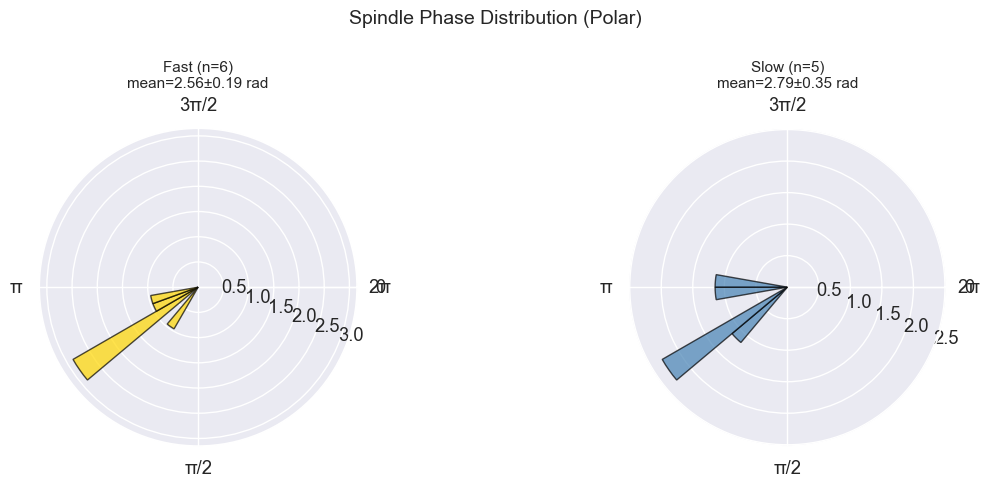

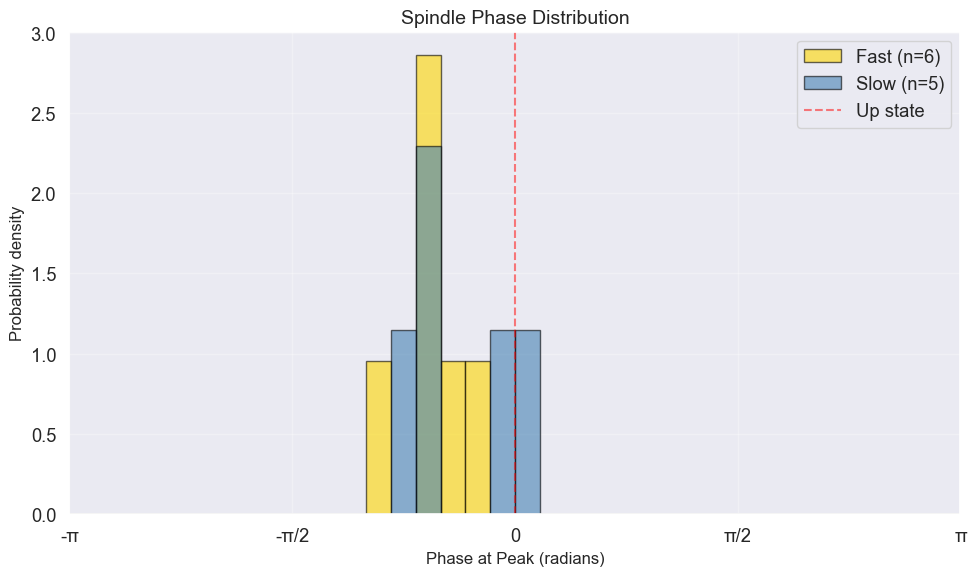

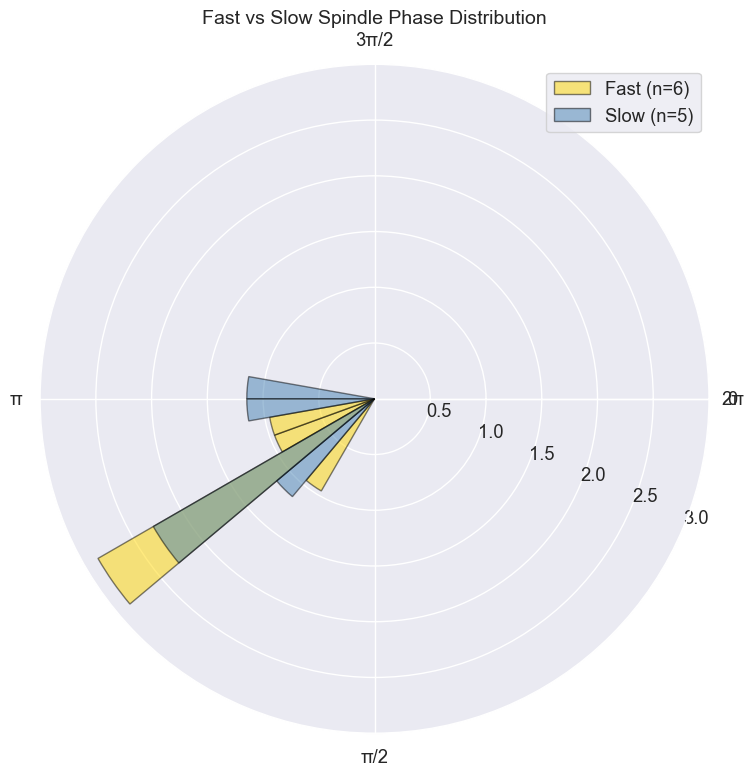

In [ ]:
# ========== 画直方图 ==========
# 提取快慢纺锤波的相位
fast_phases = result_df[result_df['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = result_df[result_df['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波数量: {len(fast_phases)}")
print(f"慢纺锤波数量: {len(slow_phases)}")

# ----- 关键：将相位从 -π~π 转换到 0~2π -----
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# 对应关系：
# 原始 -π → 0
# 原始 -π/2 → π/2
# 原始 0 → π
# 原始 π/2 → 3π/2
# 原始 π → 2π

# ----- 图1：极坐标直方图（左右并排）-----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)  # 改为 0 到 2π
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'gold'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        # 在 0~2π 范围内计算圆形统计
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    # 极坐标设置：0 在右侧，顺时针
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    # 设置刻度标签：0, π/2, π, 3π/2, 2π
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.suptitle('Spindle Phase Distribution (Polar)', fontsize=14)
plt.tight_layout()
plt.show()

# ----- 图2：线性直方图（叠加对比）-----
fig, ax = plt.subplots(figsize=(10, 6))

# 线性直方图用原始数据（-π 到 π）更方便
if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='gold', edgecolor='black', density=True, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title('Spindle Phase Distribution', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----- 图3：快慢叠加在同一极坐标图上 -----
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='gold', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title('Fast vs Slow Spindle Phase Distribution', fontsize=14)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
lajfhkl

NameError: name 'lajfhkl' is not defined

#### 查看原本汇报时参数组合中Jet18,Jer6时的直方图

筛选条件: Jet=52.3146, Jer=6.0683
总纺锤波数: 59
快纺锤波: 25
慢纺锤波: 34

快纺锤波 phase_at_peak 数量: 25
慢纺锤波 phase_at_peak 数量: 34
快纺锤波 phase_at_peak 范围: [-3.061, 2.593]
慢纺锤波 phase_at_peak 范围: [-2.888, 2.923]


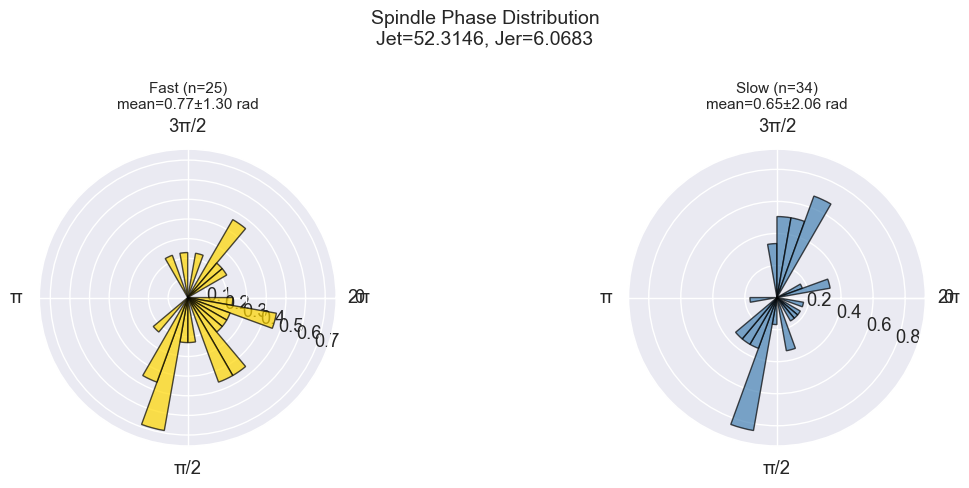

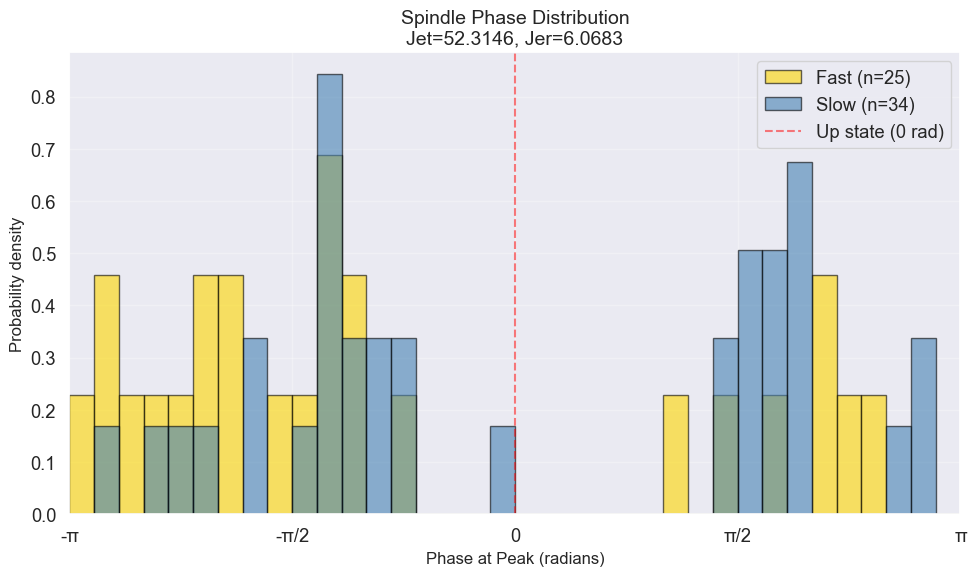

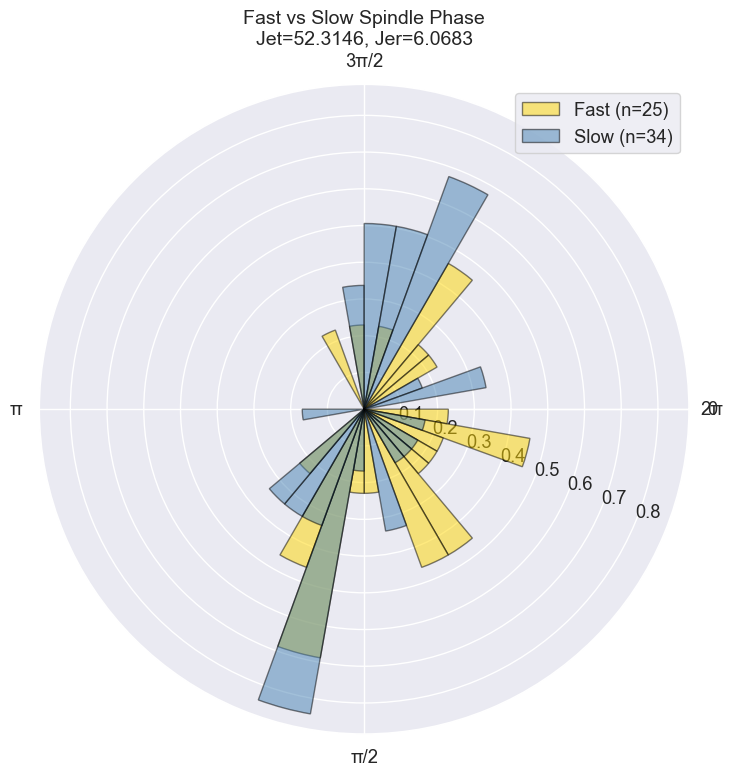


统计摘要
Fast: n=25, mean=-2.375 rad, std=1.302 rad
Slow: n=34, mean=-2.493 rad, std=2.057 rad


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 1. 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_explore_valid_limited.csv")

# ========== 2. 筛选目标参数 ==========
target_Jet = 52.3146 #18.4297
target_Jer = 6.0683

df_filtered = df[(np.abs(df['Jet'] - target_Jet) < 1e-6) & 
                 (np.abs(df['Jer'] - target_Jer) < 1e-6)]

print(f"筛选条件: Jet={target_Jet}, Jer={target_Jer}")
print(f"总纺锤波数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

# ========== 3. 提取 phase_at_peak ==========
fast_phases = df_filtered[df_filtered['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = df_filtered[df_filtered['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波 phase_at_peak 数量: {len(fast_phases)}")
print(f"慢纺锤波 phase_at_peak 数量: {len(slow_phases)}")

if len(fast_phases) > 0:
    print(f"快纺锤波 phase_at_peak 范围: [{fast_phases.min():.3f}, {fast_phases.max():.3f}]")
if len(slow_phases) > 0:
    print(f"慢纺锤波 phase_at_peak 范围: [{slow_phases.min():.3f}, {slow_phases.max():.3f}]")

# ========== 4. 将相位从 -π~π 转换到 0~2π ==========
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# ========== 5. 画极坐标直方图（左右并排）==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'gold'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.suptitle(f'Spindle Phase Distribution\nJet={target_Jet}, Jer={target_Jer}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 6. 线性直方图（叠加对比）==========
fig, ax = plt.subplots(figsize=(10, 6))

if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='gold', edgecolor='black', density=True, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Spindle Phase Distribution\nJet={target_Jet}, Jer={target_Jer}', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state (0 rad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 快慢叠加在同一极坐标图上 ==========
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='gold', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title(f'Fast vs Slow Spindle Phase\nJet={target_Jet}, Jer={target_Jer}', fontsize=14)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ========== 8. 打印统计信息 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for name, phases in [('Fast', fast_phases), ('Slow', slow_phases)]:
    if len(phases) > 0:
        mean_p = circmean(phases, low=-np.pi, high=np.pi)
        std_p = circstd(phases, low=-np.pi, high=np.pi)
        print(f"{name}: n={len(phases)}, mean={mean_p:.3f} rad, std={std_p:.3f} rad")
    else:
        print(f"{name}: 无数据")

### 慢纺锤附近正负3s内的慢波平均情况

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import glob
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
window_around_spindle = 3  # 前后各 3 秒
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数（和之前一致）
SW = {"low_freq": None, "high_freq": 3.0}

# 振幅阈值（设为0，不掩码）
amplitude_threshold = 0

# 数据路径
raw_data_dir = r"D:\mynew\demo_all\data\raw_data_scale0x0013_c2tsc0x8"
csv_path = r"D:\mynew\demo_all\data\analysis_data\spindles_all_with_mask.csv"

def get_phase_and_envelope(signal, filter_args, pad=None):
    """返回相位、滤波后的信号和包络（使用 neurolib 滤波）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    
    # 计算包络（瞬时振幅）
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    
    return phase.data.values, filtered, envelope

def extract_so_around_events(event_times_sec, V_slow, sf, window_sec=3, min_time_sec=2):
    """提取事件周围指定窗口的 SO 信号"""
    window_samples = int(window_sec * sf)
    total_duration = len(V_slow) / sf
    max_valid_time = total_duration - window_sec
    
    so_around = []
    times_sec = np.arange(-window_sec, window_sec, 1/sf)
    
    valid_times = []
    for peak_time_sec in event_times_sec:
        # 只处理不在边界的事件
        if peak_time_sec < min_time_sec or peak_time_sec > max_valid_time:
            continue
        
        peak_idx = int(peak_time_sec * sf)
        start_idx = peak_idx - window_samples
        end_idx = peak_idx + window_samples
        
        if start_idx >= 0 and end_idx < len(V_slow):
            segment = V_slow[start_idx:end_idx]
            if not np.any(np.isnan(segment)):
                so_around.append(segment)
                valid_times.append(peak_time_sec)
    
    if len(so_around) == 0:
        return np.full(len(times_sec), np.nan), np.full(len(times_sec), np.nan), np.array([]), times_sec, np.array([])
    
    so_array = np.array(so_around)
    so_mean = np.mean(so_array, axis=0)
    so_sem = np.std(so_array, axis=0) / np.sqrt(len(so_array))
    
    return so_mean, so_sem, so_array, times_sec, np.array(valid_times)

def get_down_depths(so_array, times_sec):
    """计算每个片段的 Down state 深度"""
    if len(so_array) == 0:
        return []
    down_mask = (times_sec > 0.2) & (times_sec < 1.5)
    depths = []
    for segment in so_array:
        depths.append(np.min(segment[down_mask]))
    return depths

# ========== 1. 读取 CSV 汇总文件 ==========
print("读取 CSV 汇总文件...")
df = pd.read_csv(csv_path)
print(f"CSV 列名: {df.columns.tolist()}")
print(f"CSV 总行数: {len(df)}")

# 筛选数据
df_slow = df[df['type'] == 'slow'].copy()
df_fast = df[df['type'] == 'fast'].copy()

print(f"慢纺锤波数量: {len(df_slow)}")
print(f"快纺锤波数量: {len(df_fast)}")

if len(df_slow) == 0 and len(df_fast) == 0:
    print("错误：没有纺锤波数据！")
    exit()

# ========== 2. 按 seed 分组 ==========
seed_events_slow = {}
for _, row in df_slow.iterrows():
    seed = int(row['seed'])
    peak_time = row['end']
    if seed not in seed_events_slow:
        seed_events_slow[seed] = []
    seed_events_slow[seed].append(peak_time)

seed_events_fast = {}
for _, row in df_fast.iterrows():
    seed = int(row['seed'])
    peak_time = row['end']
    if seed not in seed_events_fast:
        seed_events_fast[seed] = []
    seed_events_fast[seed].append(peak_time)

print(f"涉及 {len(seed_events_slow)} 个 seed（慢纺锤波）")
print(f"涉及 {len(seed_events_fast)} 个 seed（快纺锤波）")

# ========== 3. 获取所有 .npy 文件并建立映射 ==========
npy_files = glob.glob(os.path.join(raw_data_dir, "*.npy"))
seed_to_file = {}
for npy_file in npy_files:
    filename = os.path.basename(npy_file)
    parts = filename.replace(".npy", "").split("_")
    for i, part in enumerate(parts):
        if part == 'seed' and i + 1 < len(parts):
            seed = int(parts[i + 1])
            seed_to_file[seed] = npy_file
            break
print(f"成功映射 {len(seed_to_file)} 个 seed 到文件")

# ========== 4. 提取慢纺锤波周围的 SO 信号 ==========
all_so_slow = []
all_so_fast = []

print("\n提取慢纺锤波周围的 SO 信号...")
for seed, event_times in seed_events_slow.items():
    if seed not in seed_to_file:
        continue
    
    print(f"  seed={seed}: {len(event_times)} 个事件")
    
    # 加载数据
    data = np.load(seed_to_file[seed], allow_pickle=True).item()
    t = data["t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"    warning: 没有有效中间数据")
        continue
    
    # 构建 neurolib Signal 对象（修正：指定 time 维度）
    time_sec = t_mid / sf
    aln_xr = xr.DataArray(V_e_mid, dims=["time"], coords={"time": time_sec})
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位和滤波后的信号
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # 提取 SO 片段
    so_mean, so_sem, so_array, times, valid_times = extract_so_around_events(
        event_times, V_slow, sf, window_around_spindle, min_time_sec=2
    )
    
    if len(so_array) > 0:
        all_so_slow.extend(so_array)
        print(f"    成功提取 {len(so_array)}/{len(event_times)} 个片段")
    else:
        print(f"    0 个片段")

print(f"\n总共提取慢纺锤波片段: {len(all_so_slow)}")

print("\n提取快纺锤波周围的 SO 信号...")
for seed, event_times in seed_events_fast.items():
    if seed not in seed_to_file:
        continue
    
    print(f"  seed={seed}: {len(event_times)} 个事件")
    
    # 加载数据
    data = np.load(seed_to_file[seed], allow_pickle=True).item()
    t = data["t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"    warning: 没有有效中间数据")
        continue
    
    # 构建 neurolib Signal 对象（修正：指定 time 维度）
    time_sec = t_mid / sf
    aln_xr = xr.DataArray(V_e_mid, dims=["time"], coords={"time": time_sec})
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位和滤波后的信号
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # 提取 SO 片段
    so_mean, so_sem, so_array, times, valid_times = extract_so_around_events(
        event_times, V_slow, sf, window_around_spindle, min_time_sec=2
    )
    
    if len(so_array) > 0:
        all_so_fast.extend(so_array)
        print(f"    成功提取 {len(so_array)}/{len(event_times)} 个片段")
    else:
        print(f"    0 个片段")

print(f"\n总共提取快纺锤波片段: {len(all_so_fast)}")

if len(all_so_slow) == 0 and len(all_so_fast) == 0:
    print("\n错误：没有提取到任何纺锤波片段！")
    exit()

# ========== 5. 生成随机对照 ==========
print("\n生成随机对照...")
np.random.seed(42)

# 获取第一个可用的文件
first_seed = list(seed_to_file.keys())[0]
first_file = seed_to_file[first_seed]
data = np.load(first_file, allow_pickle=True).item()
V_e = data["V_e"]
total_duration = len(V_e) / sf

# 随机选择时间点
n_random = min(len(all_so_slow), 500) if len(all_so_slow) > 0 else 100
random_times_sec = np.random.uniform(3, total_duration - 3, n_random)

# 计算 V_slow 用于随机对照
t = data["t"]
t_min = remove_edges_samples
t_max = t[-1] - remove_edges_samples
mask = (t >= t_min) & (t <= t_max)
t_mid = t[mask]
V_e_mid = V_e[mask]

time_sec = t_mid / sf
aln_xr = xr.DataArray(V_e_mid, dims=["time"], coords={"time": time_sec})
aln_sig = RatesSignal(aln_xr)
slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)

so_mean_random, so_sem_random, so_array_random, times, _ = extract_so_around_events(
    random_times_sec, V_slow, sf, window_around_spindle, min_time_sec=2
)
print(f"随机对照: {len(so_array_random)} 个片段")

# ========== 6. 计算平均波形 ==========
mean_so_slow = np.full(len(times), np.nan)
sem_so_slow = np.full(len(times), np.nan)
mean_so_fast = np.full(len(times), np.nan)
sem_so_fast = np.full(len(times), np.nan)

if len(all_so_slow) > 0:
    mean_so_slow = np.mean(np.array(all_so_slow), axis=0)
    sem_so_slow = np.std(np.array(all_so_slow), axis=0) / np.sqrt(len(all_so_slow))

if len(all_so_fast) > 0:
    mean_so_fast = np.mean(np.array(all_so_fast), axis=0)
    sem_so_fast = np.std(np.array(all_so_fast), axis=0) / np.sqrt(len(all_so_fast))

# 计算 Down state 深度
down_depths_slow = get_down_depths(np.array(all_so_slow), times) if len(all_so_slow) > 0 else []
down_depths_fast = get_down_depths(np.array(all_so_fast), times) if len(all_so_fast) > 0 else []
down_depths_random = get_down_depths(so_array_random, times) if len(so_array_random) > 0 else []

print(f"\nDown state 深度样本数:")
print(f"  慢纺锤波: {len(down_depths_slow)}")
print(f"  快纺锤波: {len(down_depths_fast)}")
print(f"  随机: {len(down_depths_random)}")

# ========== 7. 画图 ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：三条平均波形叠加
ax = axes[0, 0]
if len(all_so_slow) > 0:
    ax.plot(times, mean_so_slow, 'b-', linewidth=2, label=f'Slow spindles (n={len(all_so_slow)})')
    ax.fill_between(times, mean_so_slow - sem_so_slow, mean_so_slow + sem_so_slow, alpha=0.2, color='blue')
if len(all_so_fast) > 0:
    ax.plot(times, mean_so_fast, 'orange', linewidth=2, label=f'Fast spindles (n={len(all_so_fast)})')
    ax.fill_between(times, mean_so_fast - sem_so_fast, mean_so_fast + sem_so_fast, alpha=0.2, color='orange')
if len(so_array_random) > 0:
    ax.plot(times, so_mean_random, 'gray', linewidth=2, label=f'Random (n={len(so_array_random)})')
    ax.fill_between(times, so_mean_random - so_sem_random, so_mean_random + so_sem_random, alpha=0.2, color='gray')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Spindle peak')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('SO amplitude (mV)', fontsize=12)
ax.set_title('SO Around Spindles vs Random', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图2：Down state 区域放大
ax = axes[0, 1]
down_mask = (times > 0.2) & (times < 1.5)
if len(all_so_slow) > 0:
    ax.plot(times[down_mask], mean_so_slow[down_mask], 'b-', linewidth=2, label='Slow spindles')
if len(all_so_fast) > 0:
    ax.plot(times[down_mask], mean_so_fast[down_mask], 'orange', linewidth=2, label='Fast spindles')
if len(so_array_random) > 0:
    ax.plot(times[down_mask], so_mean_random[down_mask], 'gray', linewidth=2, label='Random')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('SO amplitude (mV)', fontsize=12)
ax.set_title('Down State Region (0.2-1.5s after spindle)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图3：差值图
ax = axes[1, 0]
if len(all_so_slow) > 0 and len(so_array_random) > 0:
    diff_slow = mean_so_slow - so_mean_random
    ax.plot(times, diff_slow, 'b-', linewidth=2, label='Slow - Random')
if len(all_so_fast) > 0 and len(so_array_random) > 0:
    diff_fast = mean_so_fast - so_mean_random
    ax.plot(times, diff_fast, 'orange', linewidth=2, label='Fast - Random')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Difference (Spindle - Random)', fontsize=12)
ax.set_title('Enhancement Effect (Positive = Spindle increases SO)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图4：箱线图
ax = axes[1, 1]
box_data = []
box_labels = []
if len(down_depths_slow) > 0:
    box_data.append(down_depths_slow)
    box_labels.append('Slow Spindles')
if len(down_depths_fast) > 0:
    box_data.append(down_depths_fast)
    box_labels.append('Fast Spindles')
if len(down_depths_random) > 0:
    box_data.append(down_depths_random)
    box_labels.append('Random')

if len(box_data) > 0:
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
    colors_box = []
    for label in box_labels:
        if 'Slow' in label:
            colors_box.append('blue')
        elif 'Fast' in label:
            colors_box.append('orange')
        else:
            colors_box.append('gray')
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
ax.set_ylabel('Down State Depth (mV)', fontsize=12)
ax.set_title('Down State Depth Comparison', fontsize=12)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Down State Analysis: Slow vs Fast Spindles', fontsize=14)
plt.tight_layout()
#plt.savefig("analysis_data/down_state_comparison.png", dpi=150)
plt.show()

# ========== 8. 统计检验 ==========
print("\n" + "="*60)
print("统计检验（Mann-Whitney U 检验）")
print("="*60)

if len(down_depths_slow) > 0 and len(down_depths_random) > 0:
    u_slow_random, p_slow_random = mannwhitneyu(down_depths_slow, down_depths_random)
    print(f"Slow vs Random: U={u_slow_random:.0f}, p={p_slow_random:.4f}")
else:
    print("Slow vs Random: 数据不足")

if len(down_depths_fast) > 0 and len(down_depths_random) > 0:
    u_fast_random, p_fast_random = mannwhitneyu(down_depths_fast, down_depths_random)
    print(f"Fast vs Random: U={u_fast_random:.0f}, p={p_fast_random:.4f}")
else:
    print("Fast vs Random: 数据不足")

if len(down_depths_slow) > 0 and len(down_depths_fast) > 0:
    u_slow_fast, p_slow_fast = mannwhitneyu(down_depths_slow, down_depths_fast)
    print(f"Slow vs Fast: U={u_slow_fast:.0f}, p={p_slow_fast:.4f}")
else:
    print("Slow vs Fast: 数据不足")

print("\n" + "="*60)
print("Down State 深度统计摘要")
print("="*60)

if len(down_depths_slow) > 0:
    print(f"慢纺锤波: 均值={np.mean(down_depths_slow):.4f} mV, 中位数={np.median(down_depths_slow):.4f} mV, n={len(down_depths_slow)}")
if len(down_depths_fast) > 0:
    print(f"快纺锤波: 均值={np.mean(down_depths_fast):.4f} mV, 中位数={np.median(down_depths_fast):.4f} mV, n={len(down_depths_fast)}")
if len(down_depths_random) > 0:
    print(f"随机: 均值={np.mean(down_depths_random):.4f} mV, 中位数={np.median(down_depths_random):.4f} mV, n={len(down_depths_random)}")

读取 CSV 汇总文件...
CSV 列名: ['c2tsc', 'scale2', 'seed', 'type', 'start', 'peak_time', 'end', 'duration', 'frequency', 'amplitude', 'phase_at_start', 'phase_at_peak', 'phase_at_end', 'envelope_at_start', 'envelope_at_peak', 'envelope_at_end', 'masked']
CSV 总行数: 1350
慢纺锤波数量: 722
快纺锤波数量: 628
涉及 100 个 seed（慢纺锤波）
涉及 100 个 seed（快纺锤波）
成功映射 100 个 seed 到文件

提取慢纺锤波周围的 SO 信号...
  seed=1: 8 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

    成功提取 7/8 个片段
  seed=10: 9 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (fir

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


    成功提取 8/9 个片段
  seed=100: 5 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

    成功提取 4/5 个片段
  seed=11: 9 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


    成功提取 7/9 个片段
  seed=12: 7 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

    成功提取 4/7 个片段
  seed=13: 8 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

    成功提取 7/8 个片段
  seed=41: 6 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

    成功提取 5/6 个片段
  seed=42: 6 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


    成功提取 4/6 个片段
  seed=43: 11 个事件
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


KeyboardInterrupt: 

In [ ]:
alfhadfd

NameError: name 'alfhadfd' is not defined

In [ ]:

import yasa
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
'''
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)
'''
'''
sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
if sp2:
    df = sp2.summary()[["Duration", "Amplitude"]]
    min_df = df.min()
    max_df = df.max()
print(min_df, max_df)
'''
df_fast = pd.DataFrame(columns=["min", "max", "rate"])
df_slow = pd.DataFrame(columns=["min", "max", "rate"])
df_fast_a = pd.DataFrame(columns=["min", "max"])
df_slow_a = pd.DataFrame(columns=["min", "max"])
y_values = np.linspace(0.0, 0.5, 11)
print(y_values)
sf = 10000

#sp = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
for y in y_values:
    params["c2tsc"] = y
    t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
    sp1 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
    if sp1:
        print(sp1.summary())
        rate = len(sp1.summary()) / 30
        duration_data = sp1.summary()["AbsPower"]#["Duration"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val], "rate": [rate]})
        df_fast = pd.concat([df_fast, new_row], ignore_index=True)

        duration_data = sp1.summary()["RelPower"]#["Amplitude"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val]})
        df_fast_a = pd.concat([df_fast_a, new_row], ignore_index=True)
    sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,12), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
    if sp2:
        print(sp2.summary())
        rate = len(sp2.summary()) / 30
        duration_data = sp2.summary()["AbsPower"]#["Duration"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val], "rate": [rate]})
        df_slow = pd.concat([df_slow, new_row], ignore_index=True)

        duration_data = sp2.summary()["RelPower"]#["Amplitude"]#
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val]})
        df_slow_a = pd.concat([df_slow_a, new_row], ignore_index=True)

print("df_fast: ", df_fast)
print("df_slow: ", df_slow)

print("df_fast_a: ", df_fast_a)
print("df_slow_a: ", df_slow_a)



[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBacke

    Start    Peak     End  Duration  Amplitude       RMS  AbsPower  RelPower  \
0  6.3697  6.5152  7.2021    0.8324   5.706188  1.250810  0.222267  0.465632   
1  7.8361  8.1397  8.2687    0.4326   6.196756  1.286498  0.190403  0.381640   

   Frequency  Oscillations  Symmetry  Channel  IdxChannel  
0  13.038987          11.0  0.174775  CHAN000           0  
1  13.165874           6.0  0.701641  CHAN000           0  
    Start    Peak     End  Duration  Amplitude       RMS  AbsPower  RelPower  \
0  8.0498  8.2266  8.5116    0.4618   6.414371  1.435635    0.2346  0.432986   

   Frequency  Oscillations  Symmetry  Channel  IdxChannel  
0  11.133012           6.0  0.382767  CHAN000           0  


KeyboardInterrupt: 

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


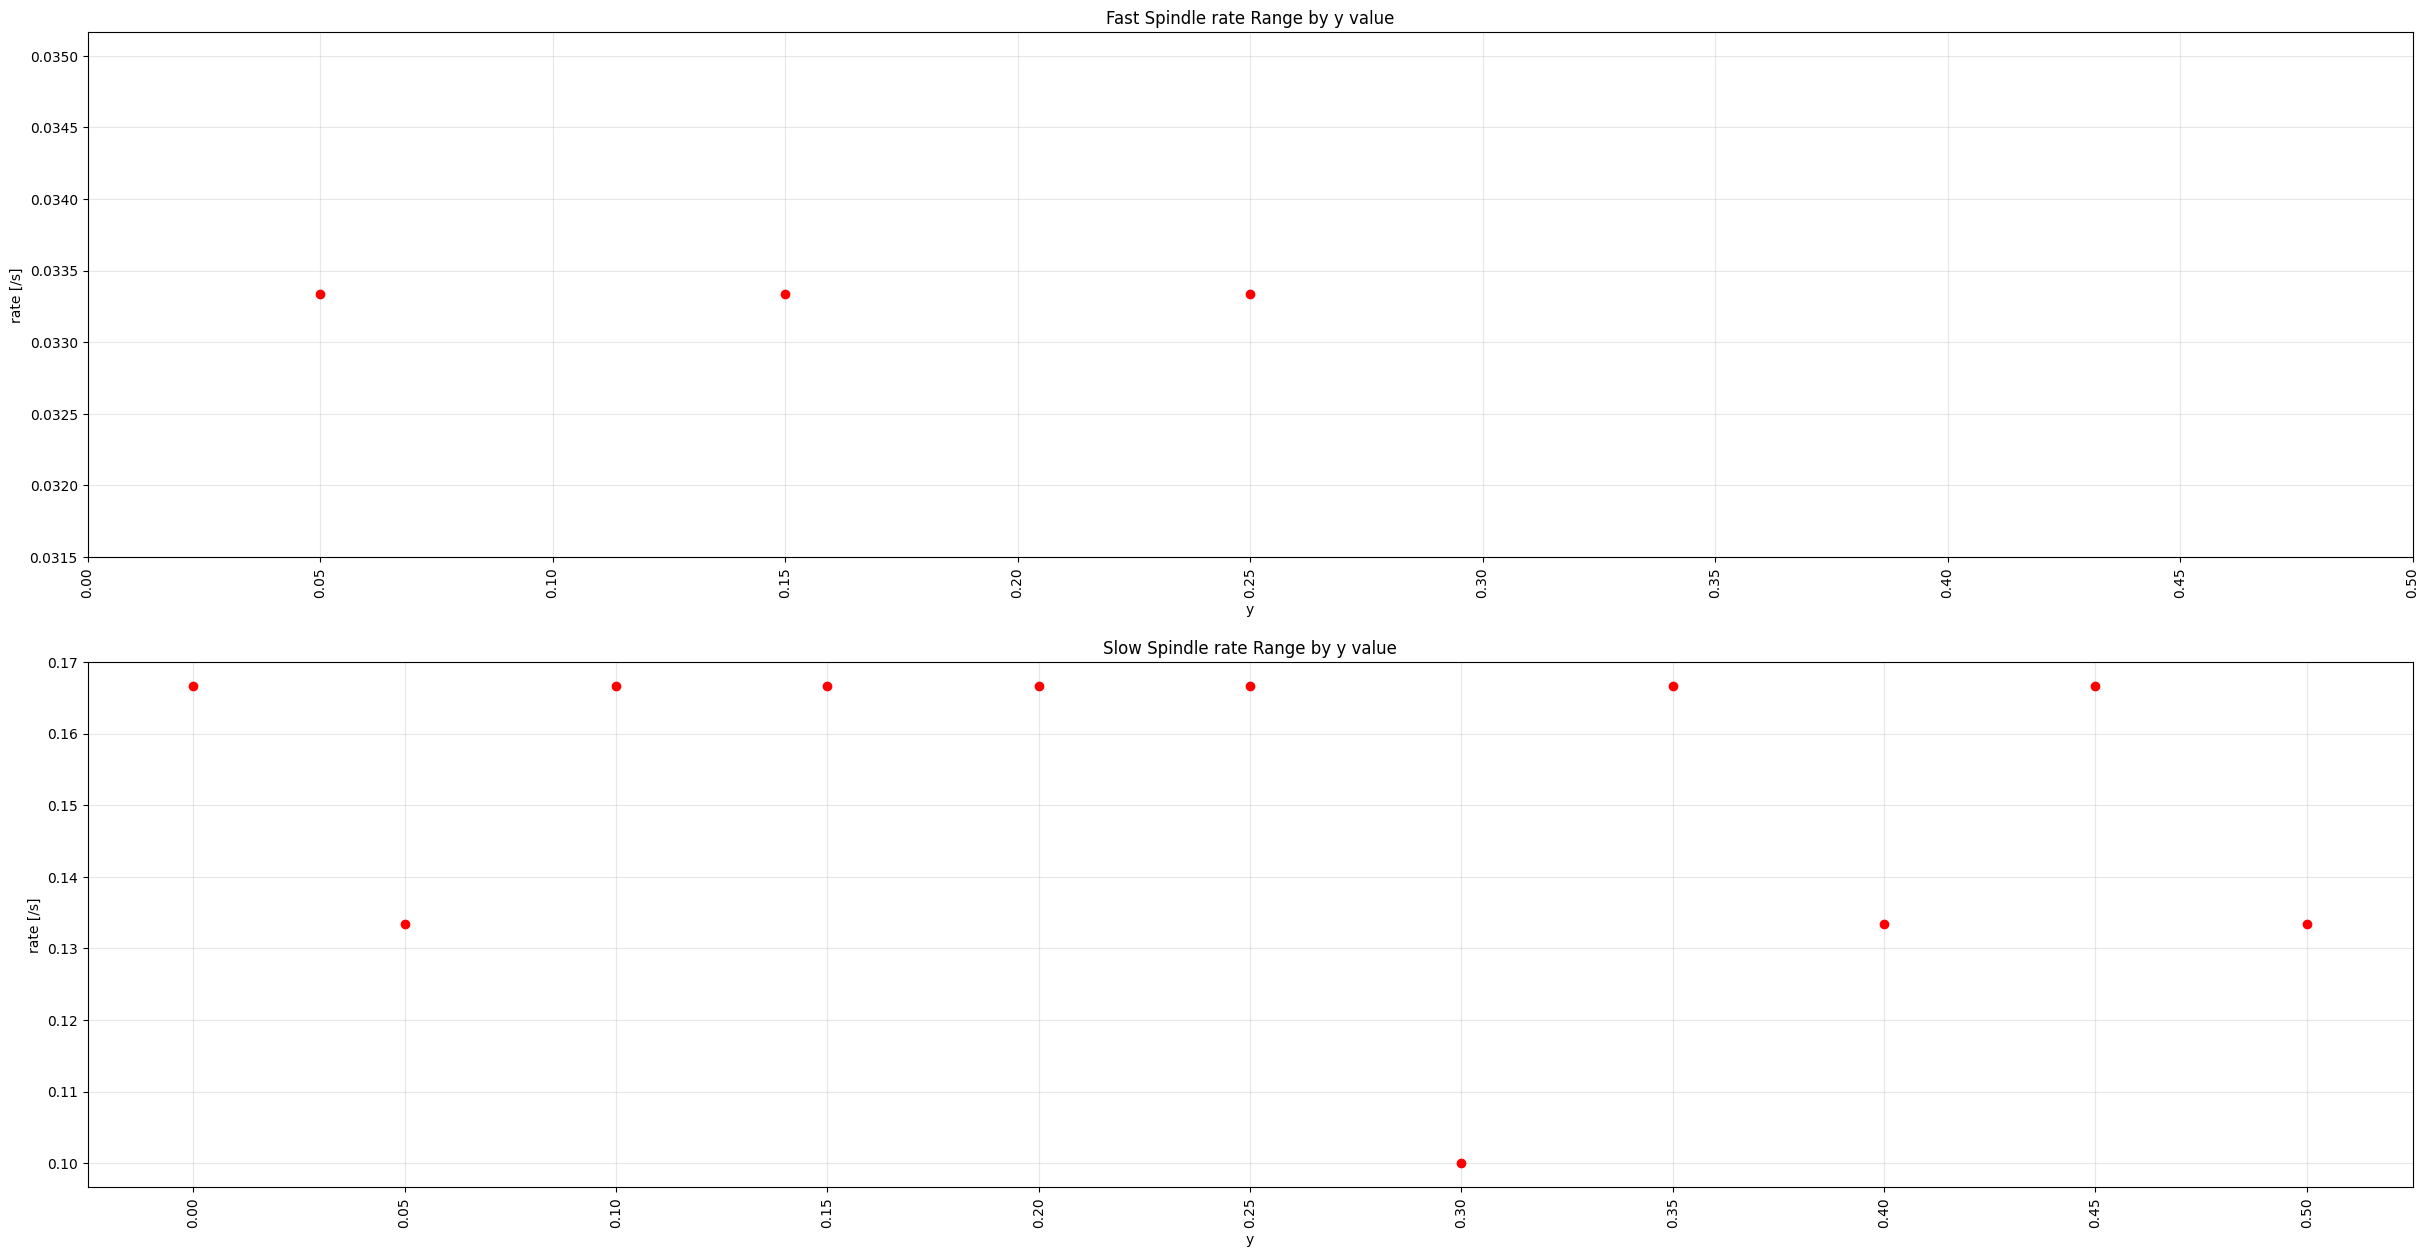

In [ ]:
# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast.iterrows():
    plt.plot(row['y'], row['rate'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('rate [/s]')
plt.title('Fast Spindle rate Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow.iterrows():
    plt.plot(row['y'], row['rate'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('rate [/s]')
plt.title('Slow Spindle rate Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()




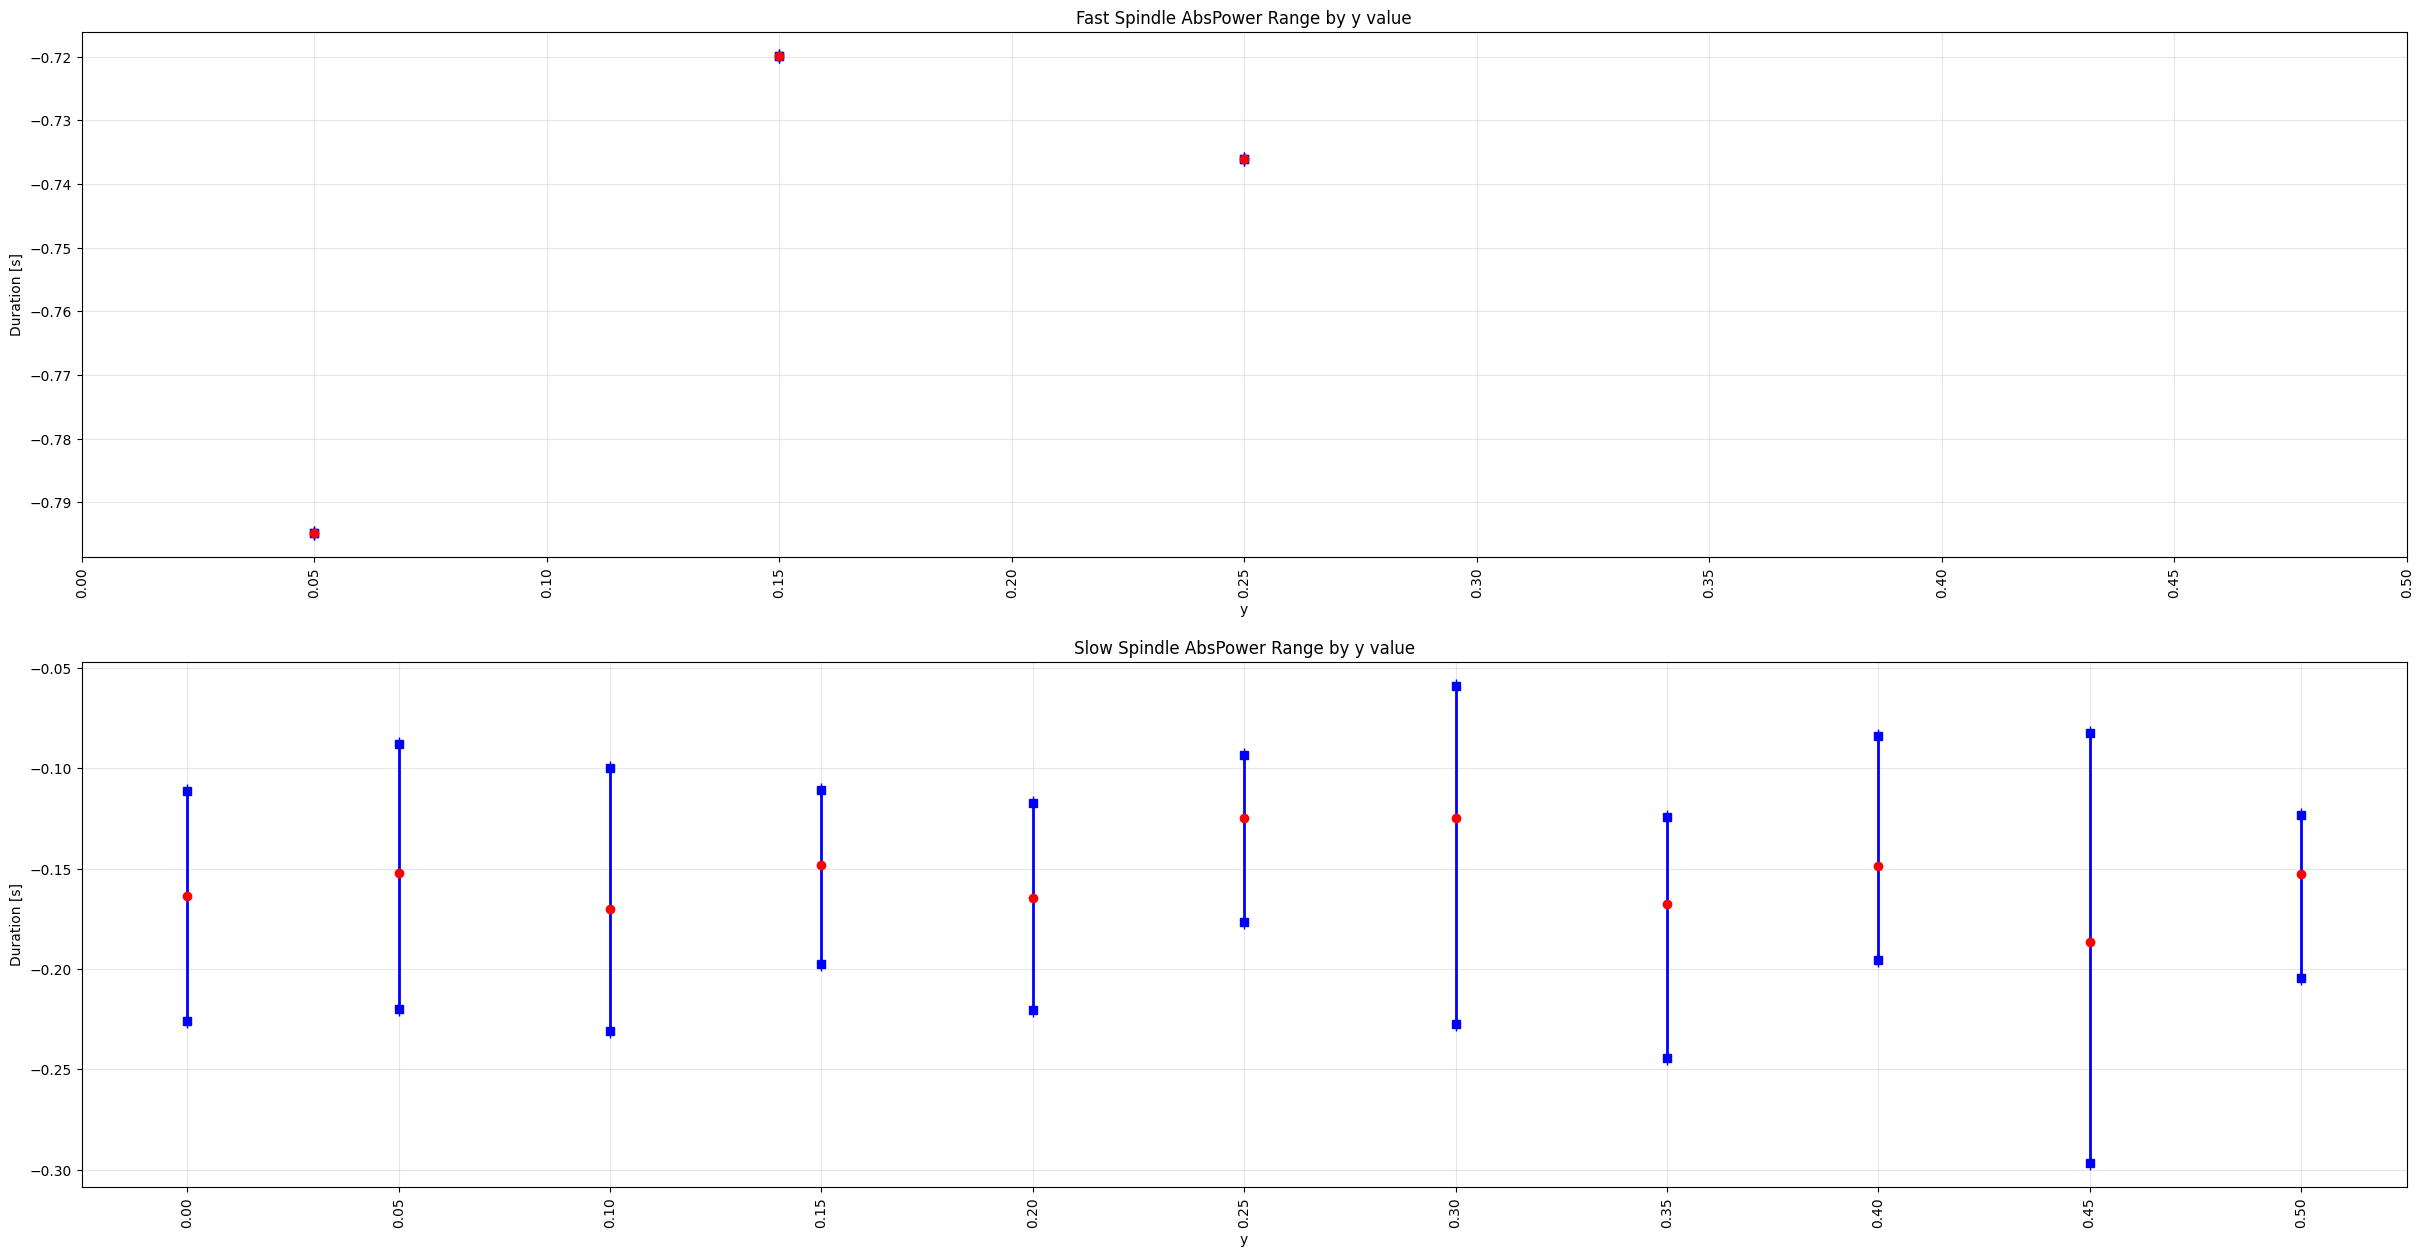

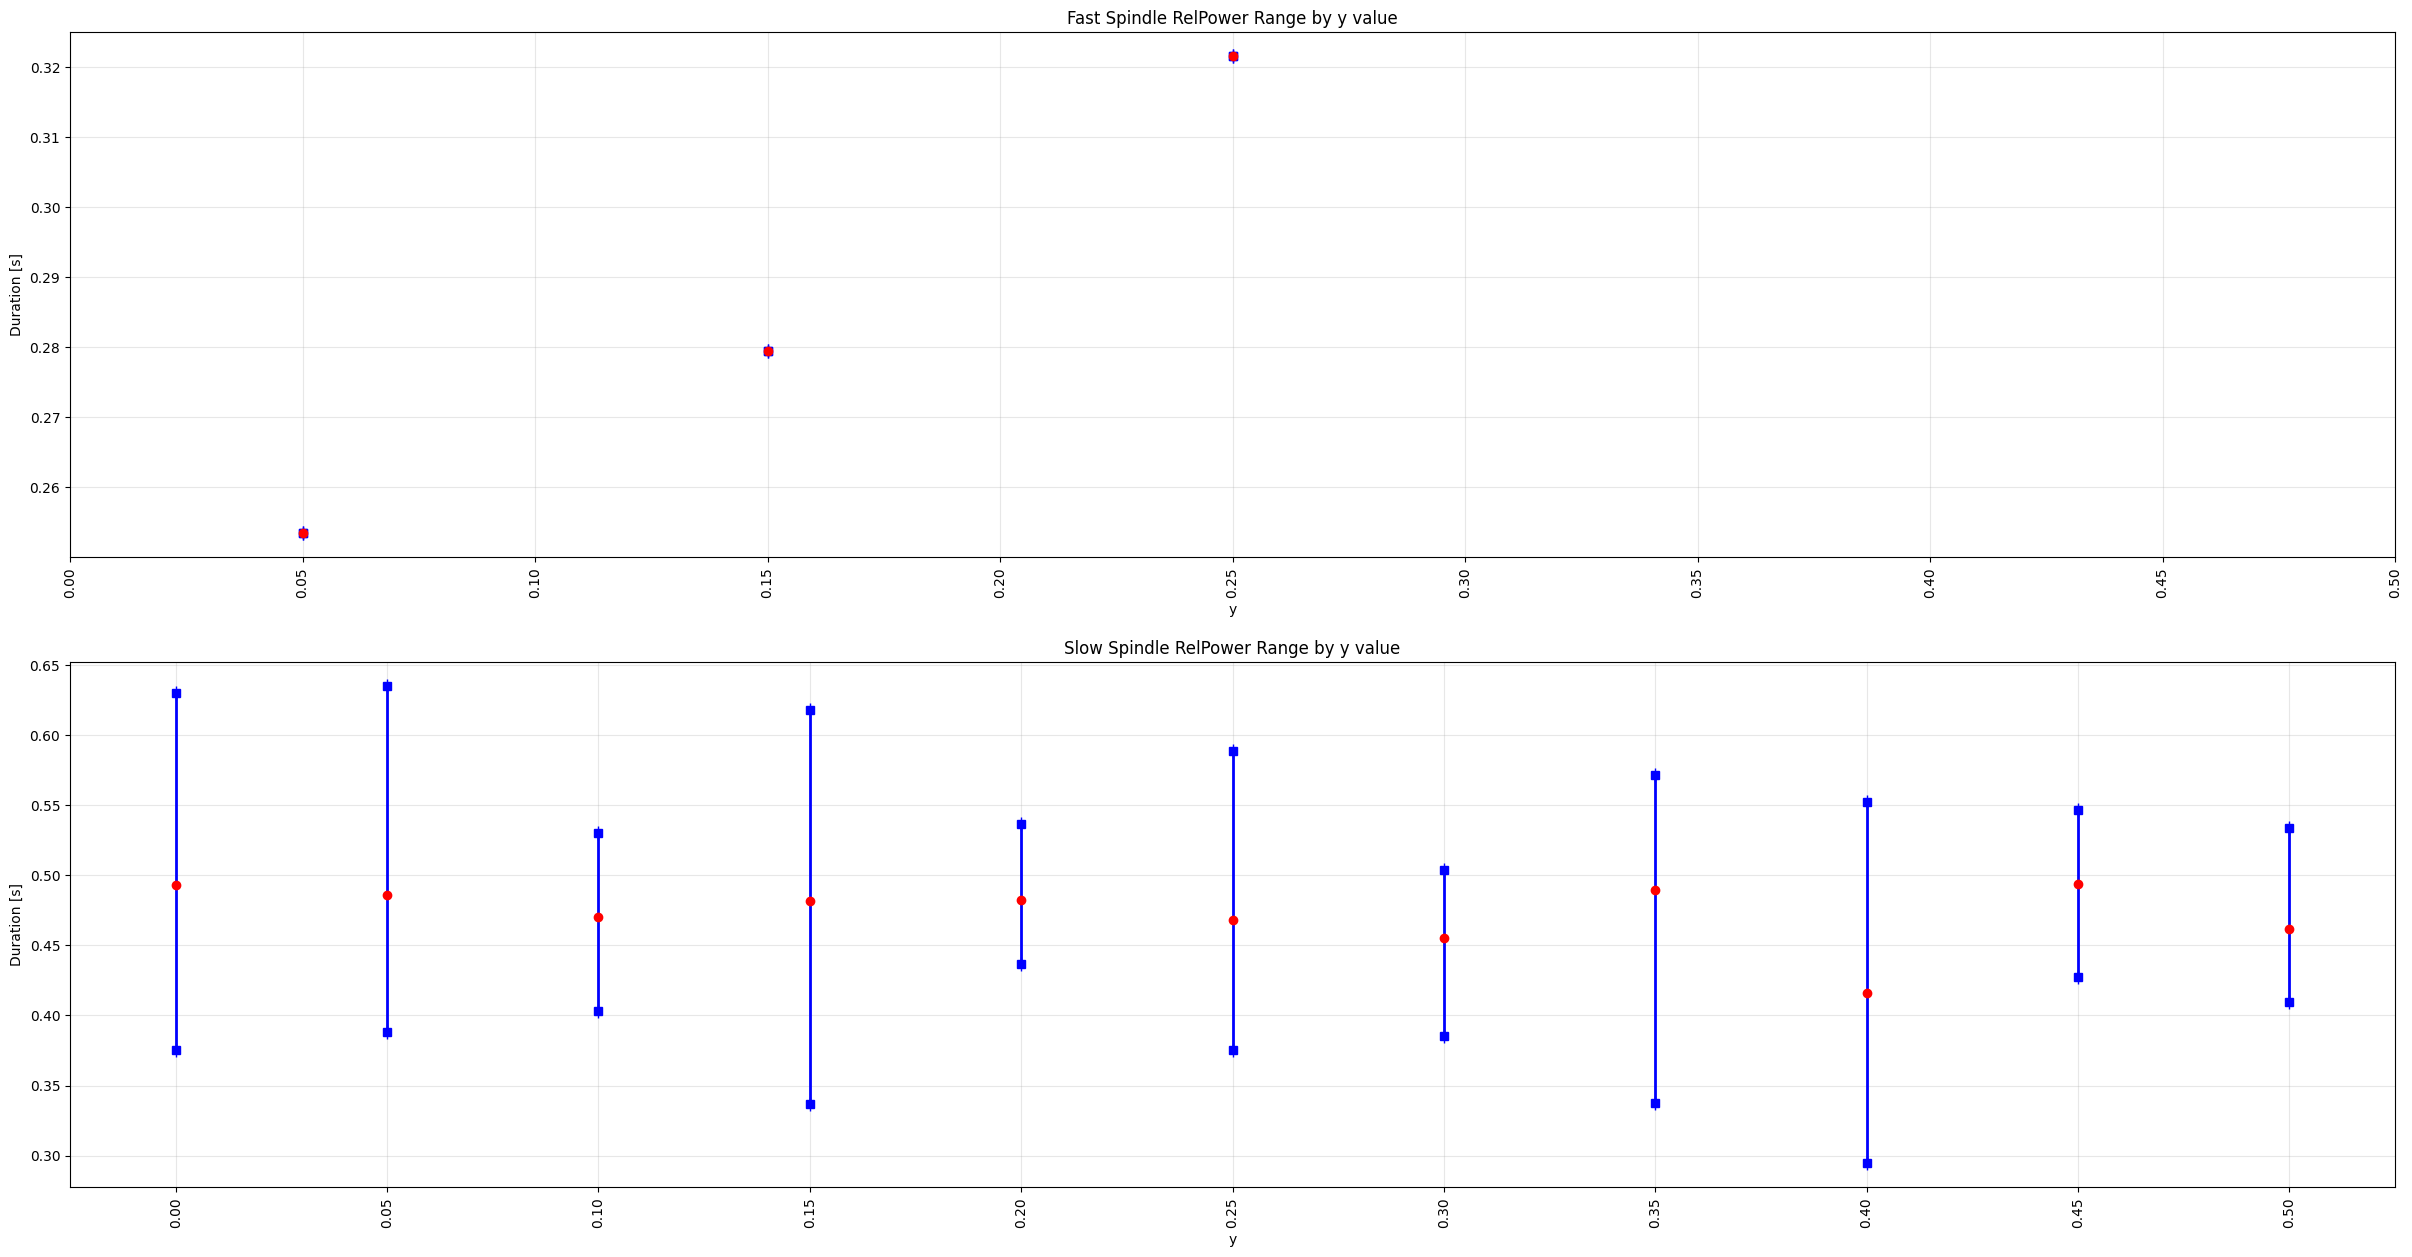

In [ ]:
# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Fast Spindle AbsPower Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Slow Spindle AbsPower Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()


# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Fast Spindle RelPower Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Slow Spindle RelPower Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()




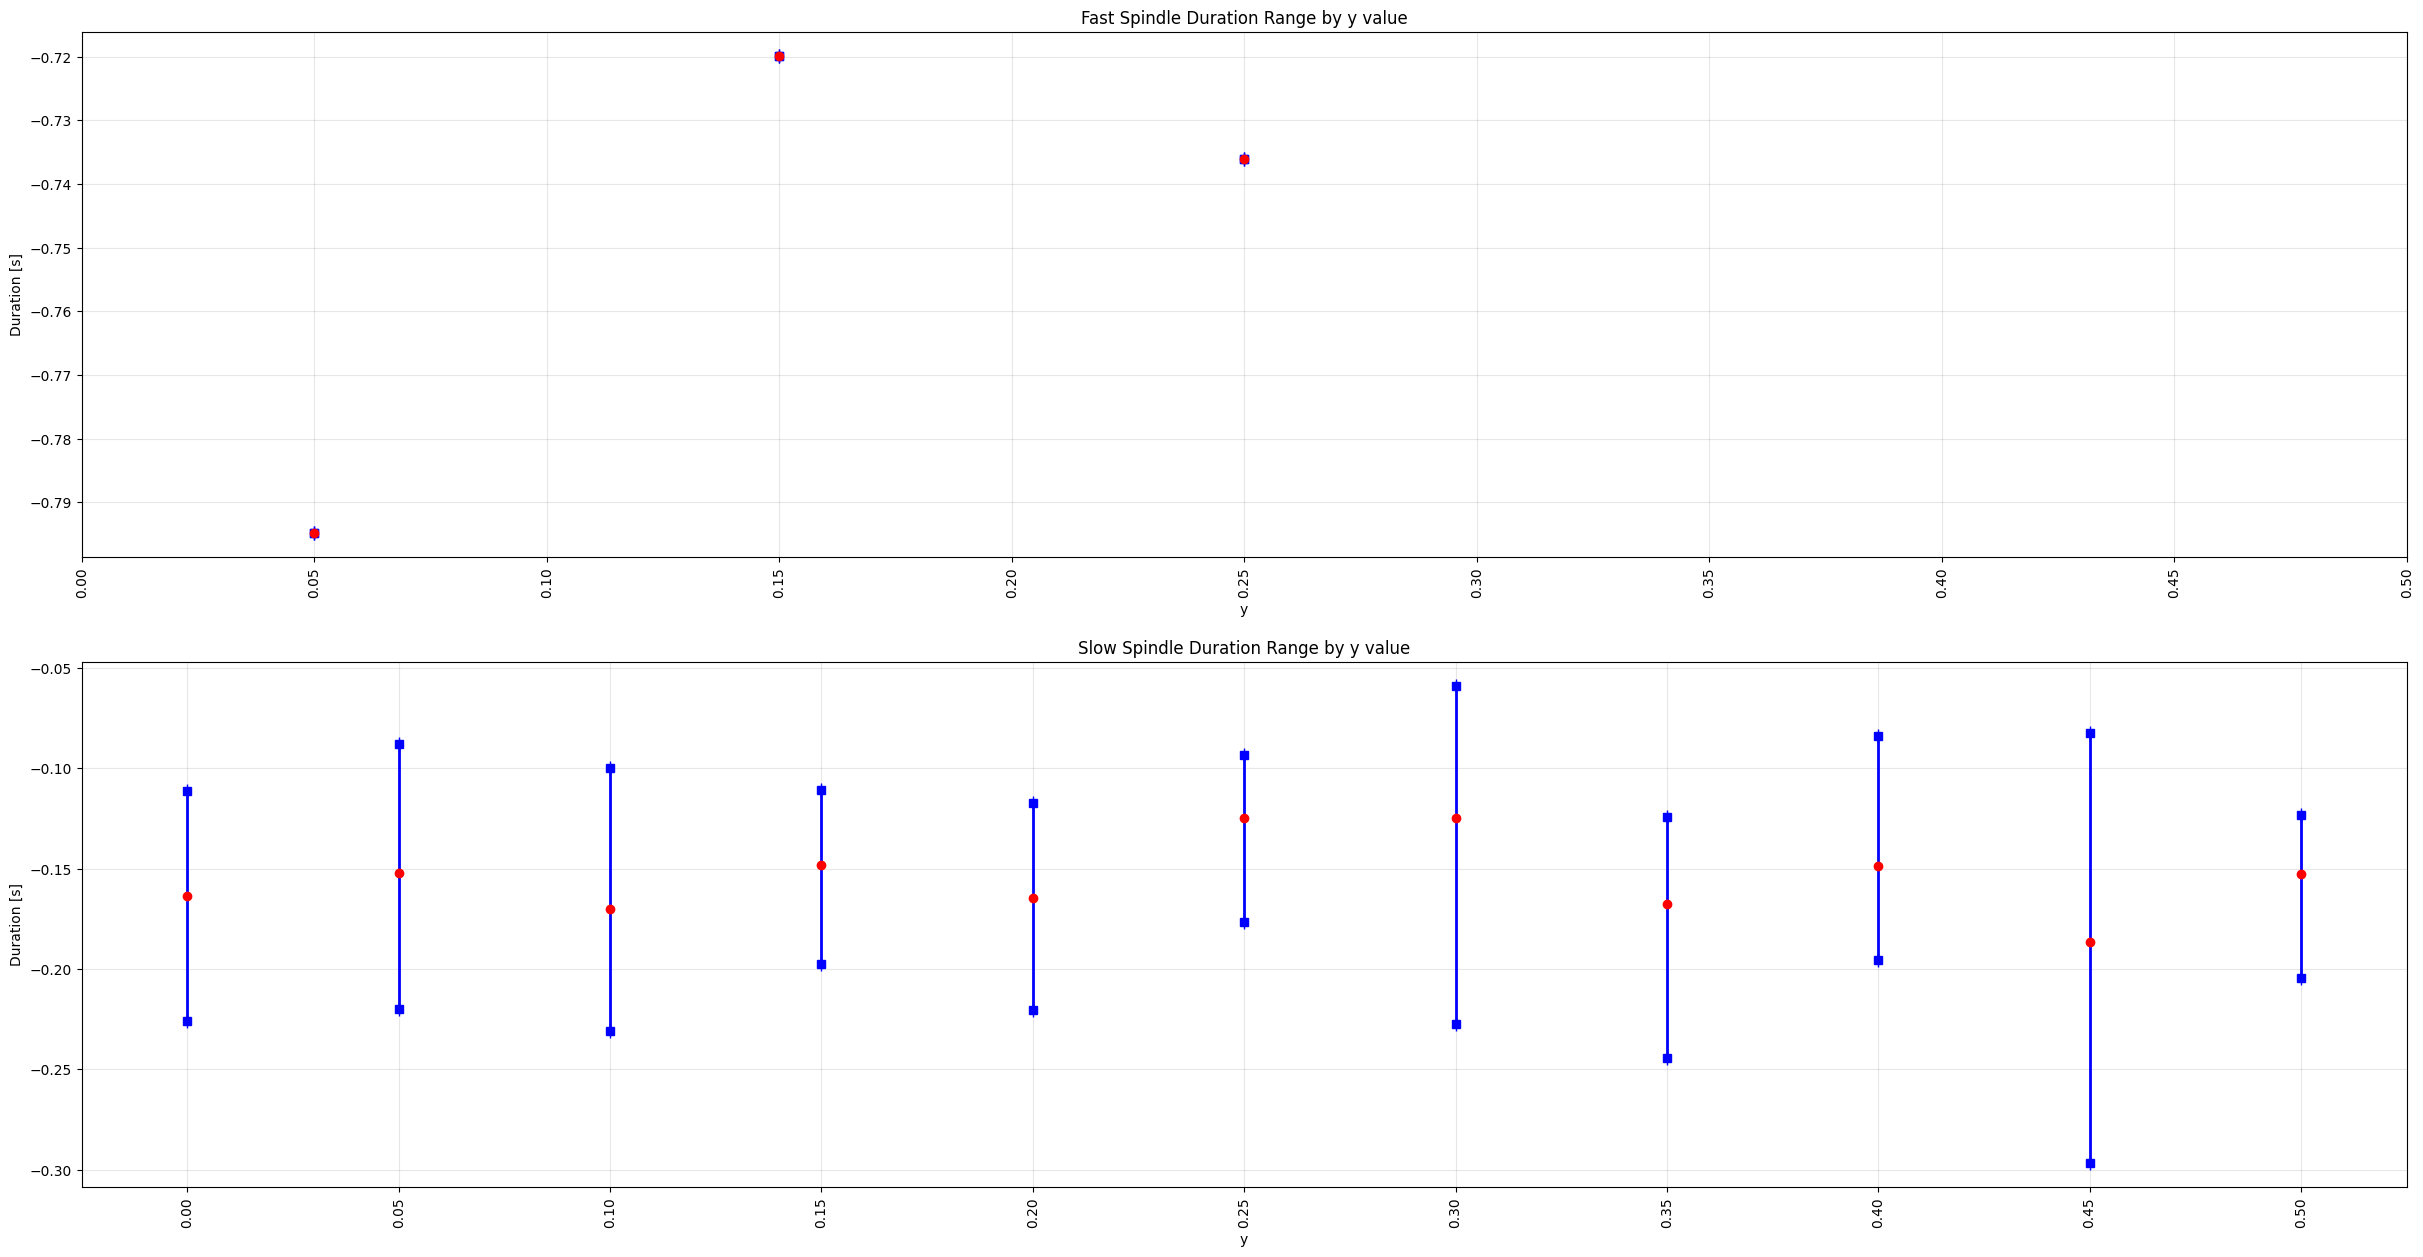

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Fast Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Slow Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()





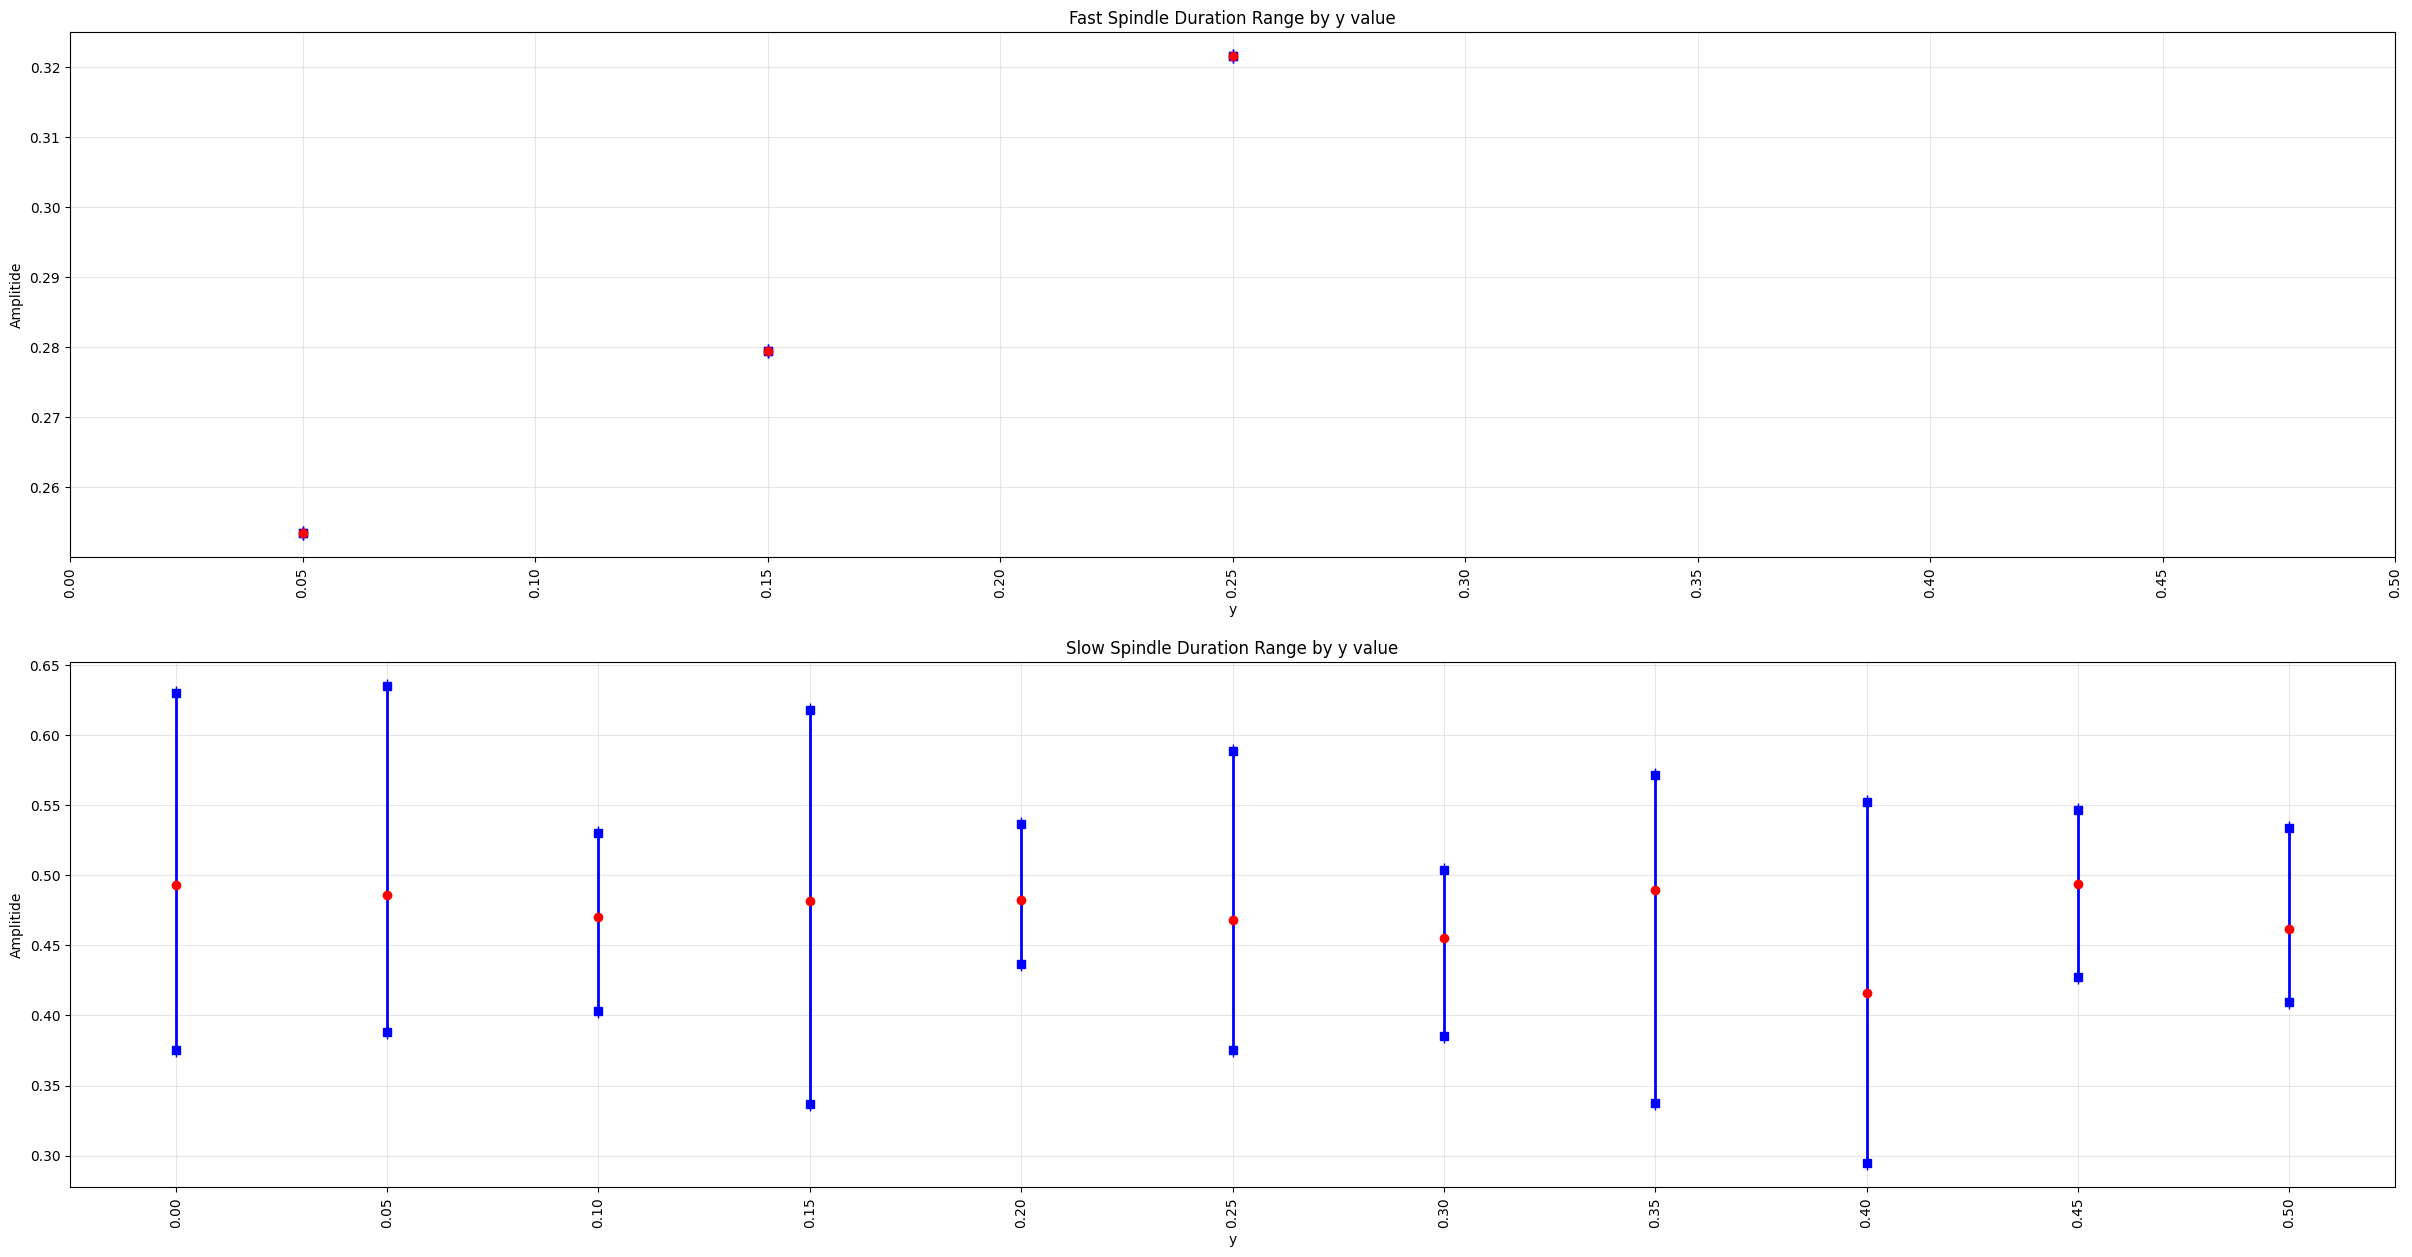

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Amplitide')      
plt.title('Fast Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Amplitide')
plt.title('Slow Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()





In [ ]:
df_fast_part = df_fast[83:90]
df_fast_part["y_1"]  = df_fast_part["y"] / (-10)
print(df_fast_part)
df_slow_part = df_slow[83:90]
df_slow_part["y_1"]  = df_slow_part["y"] / (-10)
print(df_slow_part)

Empty DataFrame
Columns: [min, max, rate, y, mean, y_1]
Index: []
Empty DataFrame
Columns: [min, max, rate, y, mean, y_1]
Index: []


[0.555 0.56  0.565 0.57  0.575 0.58  0.585]


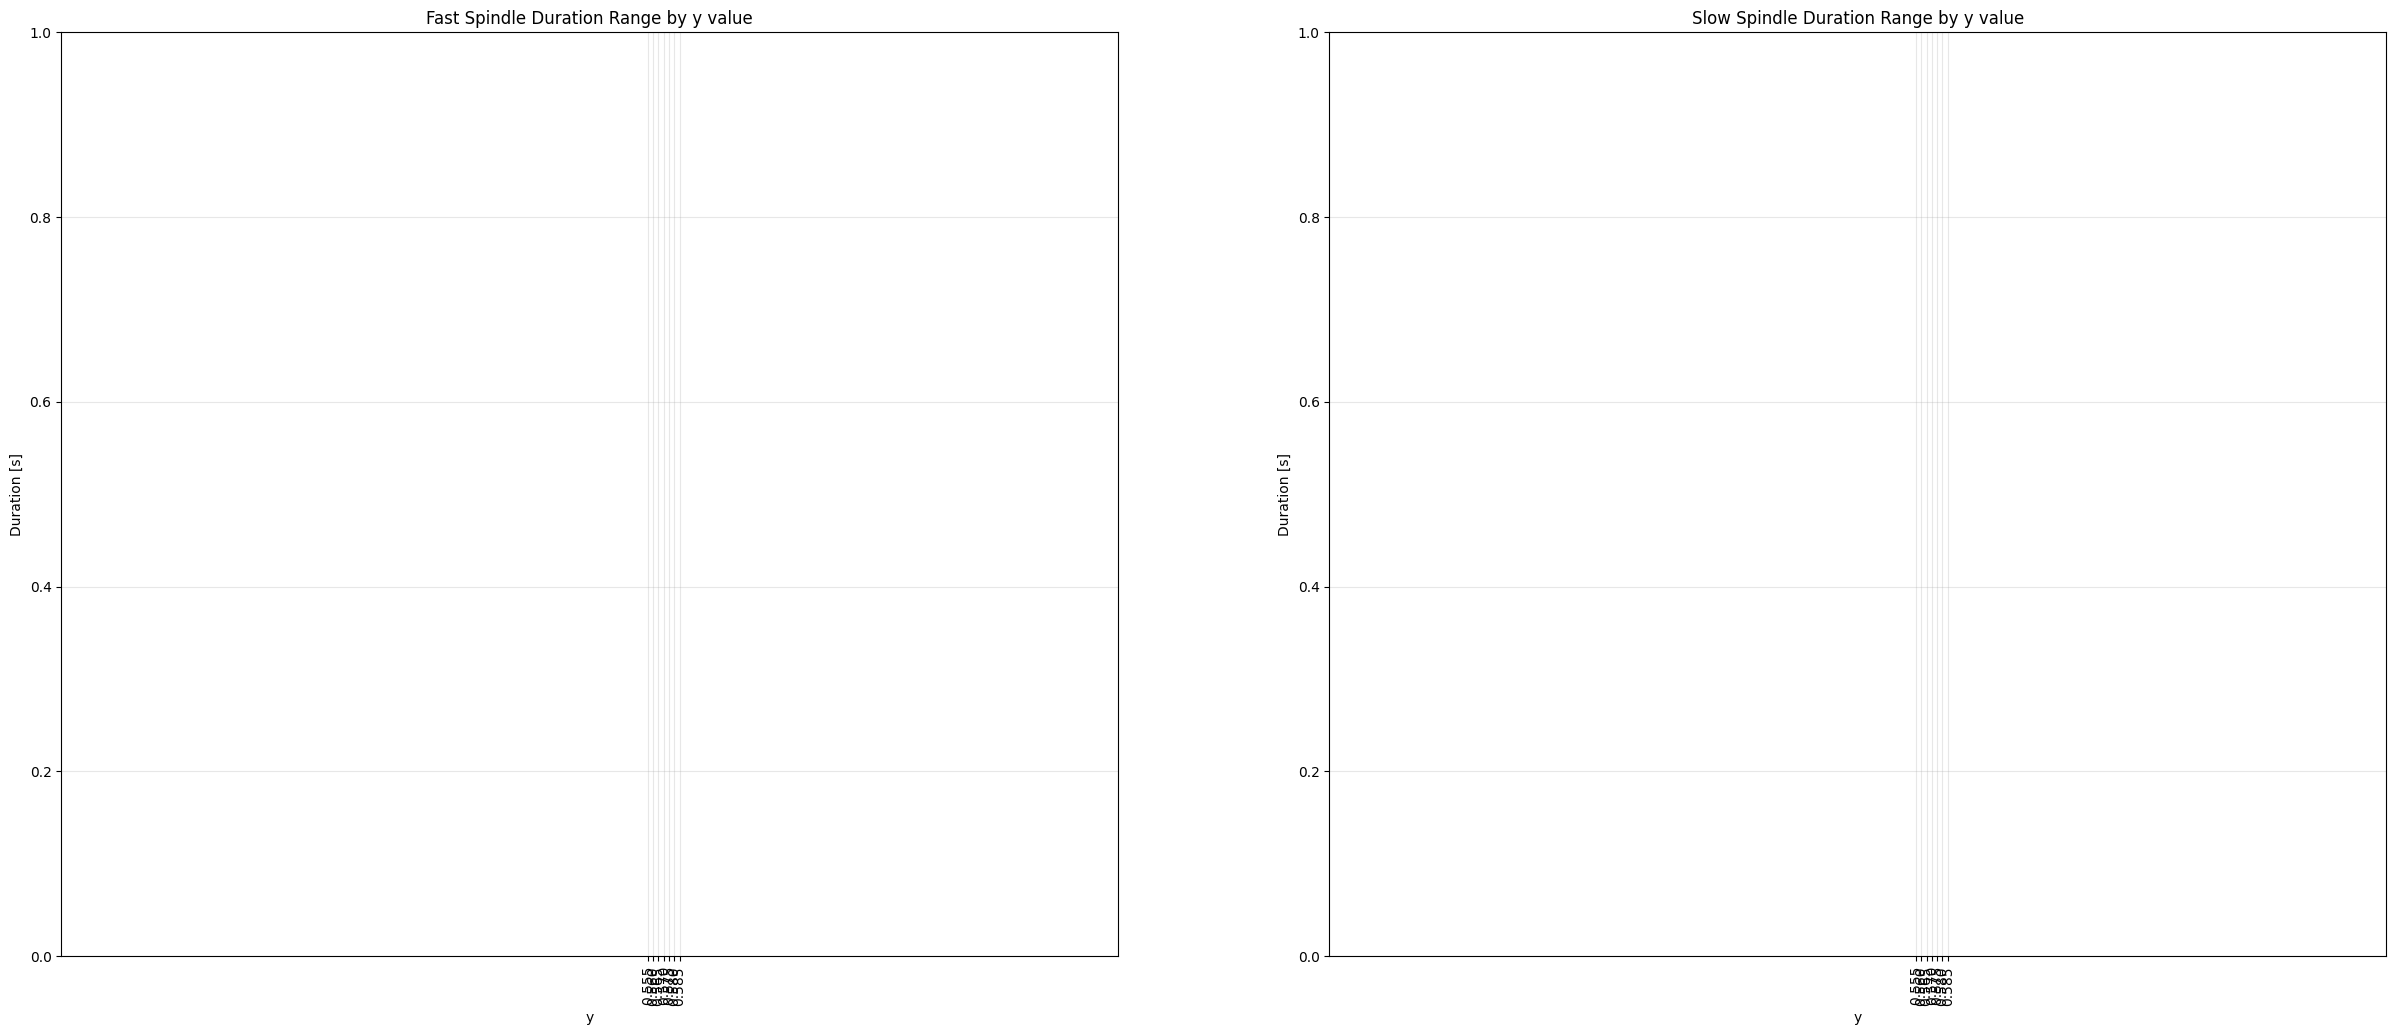

In [ ]:
x = np.linspace(-5.55,-5.85, 7) / -10
print(x)
#fig, ax = plt.subplots(1,2, figsize=(30, 12))
fig = plt.subplots(figsize=(30, 12))

ax1 = plt.subplot(1,2,1)
# 对每个y值画一条竖线
for idx, row in df_fast_part.iterrows():
    #plt.plot([row['y'], row['y']], [row['min'], row['max']], 
    #         'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    #plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y_1'], row['max'], 'bs', markersize=6)
    #plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Fast Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(x, rotation=90)

ax2 = plt.subplot(1,2,2,sharey=ax1)
# 对每个y值画一条竖线
for idx, row in df_slow_part.iterrows():
    #plt.plot([row['y'], row['y']], [row['min'], row['max']], 
    #         'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    #plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y_1'], row['max'], 'bs', markersize=6)
    #plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Slow Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(x, rotation=90)

plt.show()


In [ ]:
daff

NameError: name 'daff' is not defined

In [ ]:

import yasa
import xarray as xr
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
'''
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)
'''
sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
print("TCR:",sp2.summary()["Duration"]) if sp2 else  print("NO Fast spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate2 = len(sp2._events) / duration if sp2 else 0
print("Fast spindles:", rate2)

sp4 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,13), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.60, "rms":1.5})
print("TCR:",sp4.summary()) if sp4 else  print("NO Slow spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate4 = len(sp4._events) / duration if sp4 else 0
print("Slow spindles:", rate4)



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


10000.0
TCR: 0    0.4497
1    0.3038
2    0.3183
3    0.5047
4    0.3857
5    0.4517
Name: Duration, dtype: float64
Fast spindles: 0.2
TCR:      Start     Peak      End  Duration  Amplitude       RMS  AbsPower  \
0   0.4399   0.5090   0.8949    0.4550   3.697100  0.881059 -0.002345   
1   9.5539   9.7374   9.9109    0.3570   4.338686  0.997030  0.023408   
2  10.9234  11.1419  11.3339    0.4105   4.167376  0.859556  0.009797   
3  14.2442  14.8474  14.9094    0.6652   3.319859  0.806558 -0.048121   
4  16.1445  16.5441  16.9838    0.8393   4.081227  0.913120  0.017381   
5  17.7698  18.1231  18.3273    0.5575   4.258902  0.931602 -0.006218   
6  18.7157  18.8077  19.0372    0.3215   4.244325  0.954501  0.049603   
7  21.3617  21.4671  21.7143    0.3526   3.710703  0.893011  0.000785   
8  22.0874  22.6819  22.7940    0.7066   2.870893  0.711387 -0.113076   
9  25.7945  26.2045  26.4798    0.6853   4.395824  1.044749  0.176256   

   RelPower  Frequency  Oscillations  Symmetry  Channel 

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


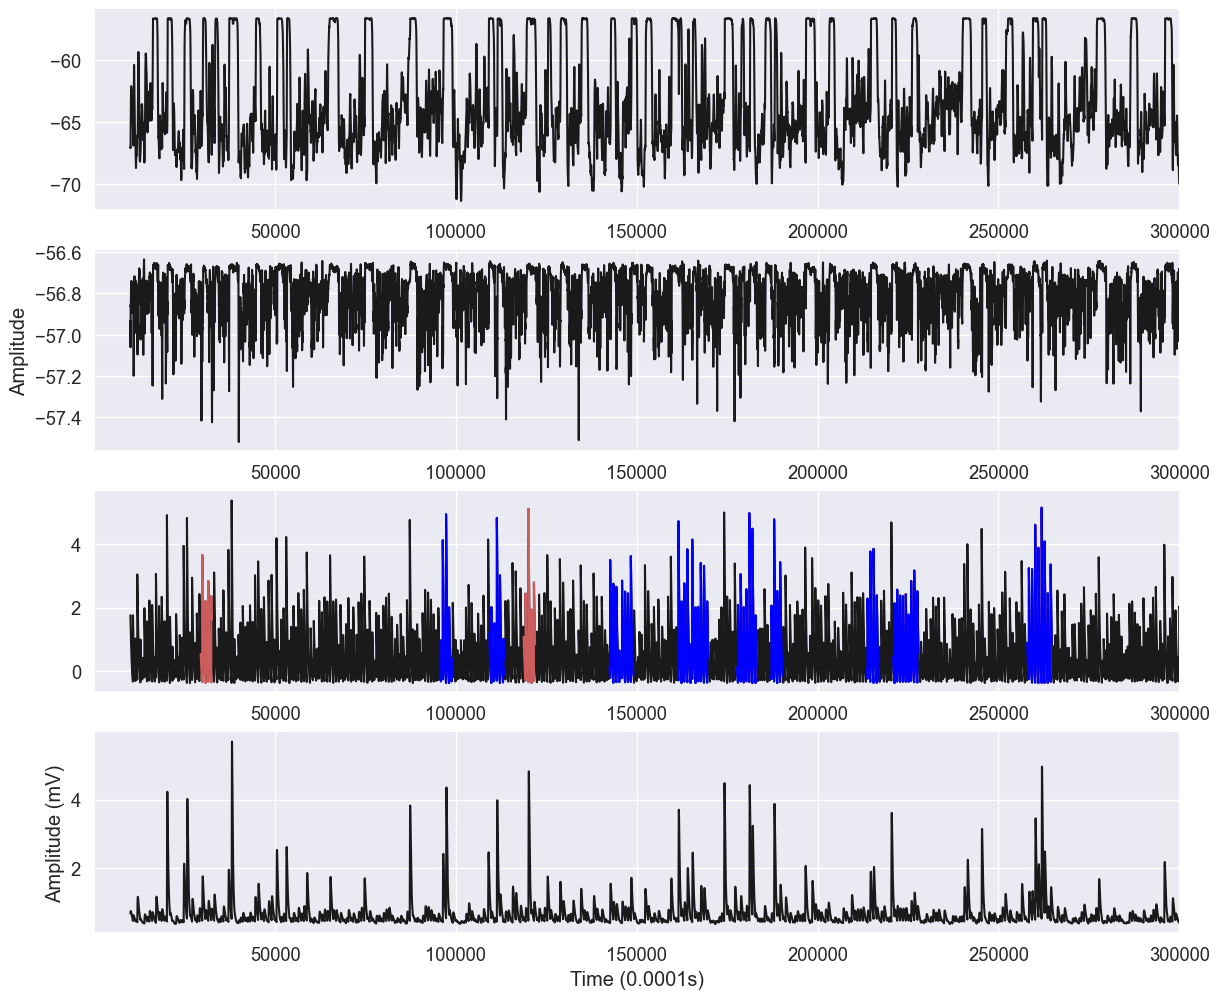

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(4, 1, figsize=(14, 12))

#plt.title('N2 sleep EEG data (2 spindles)')

#plt.setp(ax, xlim=(t[10000:].min(), t[10000:].max()))
#plt.setp(ax, xlim=(t[10000:50000].min(), t[10000:50000].max()))
plt.setp(ax, xlim = (t.min(), t.max()))
#plt.xlim([t[10000:].min()/10000, t[10000:].max()/10000])

plt.subplot(4,1,1)
plt.plot(t[10000:], V_e[10000:], lw=1.5, color='k')
#plt.plot(t[10000:], Q_e[10000:]*1000, lw=1.5, color='k')
'''
if sp1:
    mask1 = sp1.get_mask()
    spindles_highlight_e = Q_e * mask1
    spindles_highlight_e[spindles_highlight_e == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight_e[10000:]*1000, 'indianred')
'''
plt.subplot(4,1,2)
plt.plot(t[10000:], V_i[10000:], lw=1.5, color='k')
#plt.plot(t, Q_i*1000, lw=1.5, color='k')
plt.ylabel('Amplitude')


plt.subplot(4,1,3)
#plt.plot(t, V_t, lw=1.5, color='k')
plt.plot(t[10000:], V_t[10000:], lw=1.5, color='k')

if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'indianred')

if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = V_t * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'blue')



plt.subplot(4,1,4)
#plt.plot(t, V_r, lw=1.5, color='k')
plt.plot(t[10000:], V_r[10000:], lw=1.5, color='k')
plt.xlabel('Time (0.0001s)')
plt.ylabel('Amplitude (mV)')


sns.despine()

In [ ]:
# for CFC
from statistical_testing import get_p_values
from xfreq import (
    XFreqEvaluateSignal,
    kullback_leibler_modulation_index,
    mean_vector_length,
    mutual_information,
    phase_locking_value,
)
from neurolib.utils.signal import Signal, RatesSignal 
from utils import dummy_detect_down_states, get_amplitude, get_dummy_so_phase, get_phase
import pandas as pd 
import xarray as xr 
from itertools import tee
# for circ
from scipy.stats import circmean, circstd
from spindle_detection import down_state_to_spindle_pow_max_peak
# for TF
from yasa import get_centered_indices, stft_power
import matplotlib as mpl

results_df = pd.DataFrame(
    {
        "ALN": Q_e * 1000.0,
        "TCR": V_t, # 这里用Q行吗？
    },
    index=t/10000,
)
results_df.index.name = "time"

aln_xr = xr.DataArray(results_df["ALN"])
tcr_xr = xr.DataArray(results_df["TCR"])
aln_sig = RatesSignal(aln_xr)
tcr_sig = RatesSignal(tcr_xr)


Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 16501 samples (1.650 sec)

(300000,)
(300000,)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


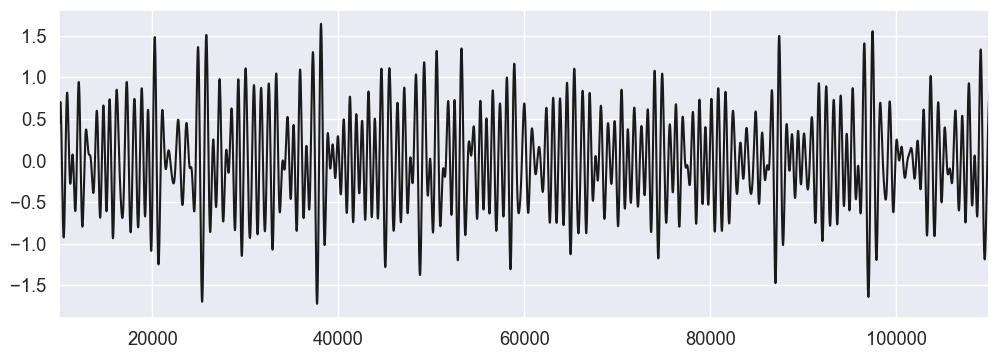

In [ ]:
import matplotlib.pyplot as plt
# V_t after filter (tcr_sig) (how?)
pad = 5.0
filter_args1={"low_freq": 12.0, "high_freq": 16.0}
filter_args2={"low_freq": 8.0, "high_freq": 12.0}
filter_args3={"low_freq": 8.0, "high_freq": 16.0}


tcr_filter = tcr_sig.detrend(inplace=False)
if 0:#pad:
    tcr_filter.pad(
        how_much=pad, in_seconds=True, padding_type="reflect", side="both"
    )
#tcr_filter.filter(**filter_args1)
tcr_filter.filter(**filter_args3)
print(tcr_filter.data.values.shape)
print(t.shape)
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

plt.setp(ax, xlim=(t[10000:110000].min(), t[10000:110000].max()))

plt.subplot(1,1,1)
plt.plot(t[10000:110000], tcr_filter.data.values[10000:110000], lw=1.5, color='k')



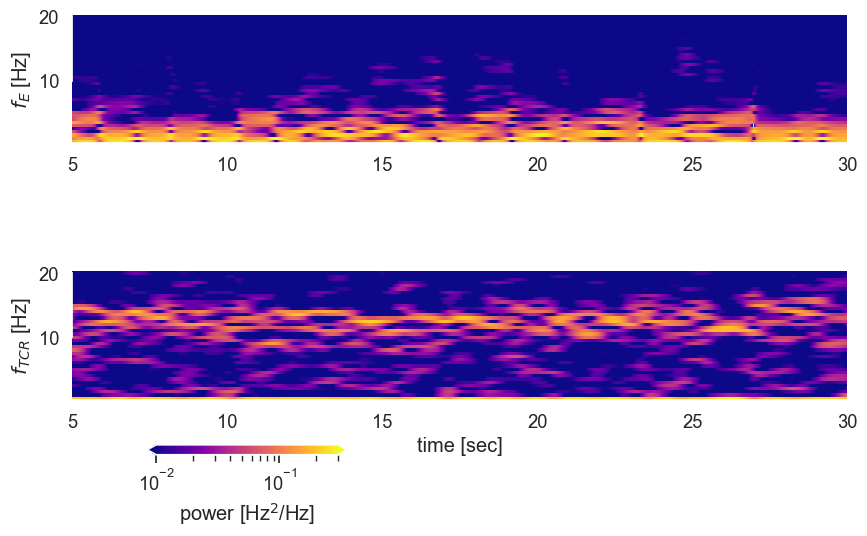

In [ ]:

# TFR plot ALN and TCR (results_df) (how?)
CMAP = "plasma"
SXX_EPS = 1.1e-3

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(nrows=2, ncols=1)
gs.update(wspace=1, hspace=1.0)

sampling_freq = 1.0 / (results_df.index[1] - results_df.index[0])
window = 2.0  # seconds
step = 0.2  # seconds
freqs_bounds = (0.1, 20.0)
vmin = 0.01
vmax = 0.3
stft_axs = []
for ii, node in enumerate(["ALN", "TCR"]):
    f, _, Sxx = stft_power(
        results_df[node],
        sampling_freq,
        window=window,
        step=step,
        band=freqs_bounds,
        norm=True,
        interp=True,
    )
    ax = fig.add_subplot(gs[ii,0])
    stft_axs.append(ax)
    ax.pcolormesh(
        results_df.index,
        f,
        Sxx + SXX_EPS,
        cmap=CMAP,
        rasterized=True,
        norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.grid()
    ax.set_ylabel(f"$f_{{{'TCR' if node == 'TCR' else 'E'}}}$ [Hz]")
    sns.despine(trim=True, ax=ax)
    ax.set_xlim([5, 30])
ax.set_xlabel("time [sec]")
cbar_ax = fig.add_axes([0.2, 0.0, 0.2, 0.02])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax,
    cmap=plt.get_cmap(CMAP),
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    orientation="horizontal",
    extend="both",
)
cbar.set_label("power [Hz$^{2}$/Hz]")

In [ ]:
dfsfa

NameError: name 'dfsfa' is not defined

In [ ]:


## 极坐标图像 (results_df, aln_sig, tcr_sig)
POLAR_XTICKS = np.pi / 180.0 * np.array([0, 90, 180, 270])
POLAR_XTICKLABELS = ["0", r"$\pi/2$", r"$\pi$", r"$-\pi/2$"]

SW = {"low_freq": None, "high_freq": 3.0}
SP_FAST = {"low_freq": 12.0, "high_freq": 16.0}
SP_SLOW = {"low_freq": 8.0, "high_freq": 12.0}
SP_FULL = {"low_freq": 8.0, "high_freq": 16.0}

'''
def get_phase(signal, filter_args, pad=None):
    """
    Extract phase of the signal. Steps: detrend -> pad -> filter -> Hilbert
    transform -> get phase -> un-pad.

    :param signal: signal to get phase from
    :type signal: `neurolib.utils.signal.Signal`
    :param filter_args: arguments for `Signal`'s filter method (see its
        docstring)
    :type filter_args: dict
    :param pad: how many seconds to pad, if None, won't pad
    :type pad: float|None
    :return: wrapped Hilbert phase of the signal
    :rtype: `neurolib.utils.signal.Signal`
    """
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase


def get_amplitude(signal, filter_args, pad=None):
    """
    Extract amplitude of the signal. Steps: detrend -> pad -> filter -> Hilbert
    transform -> get amplitude -> un-pad.

    :param signal: signal to get amplitude from
    :type signal: `neurolib.utils.signal.Signal`
    :param filter_args: arguments for `Signal`'s filter method (see its
        docstring)
    :type filter_args: dict
    :param pad: how many seconds to pad, if None, won't pad
    :type pad: float|None
    :return: Hilbert amplitude of the signal
    :rtype: `neurolib.utils.signal.Signal`
    """
    assert isinstance(signal, Signal)
    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude

'''
def so_phase_while_spindle(so_phase, spindle_amp, down_state_centers, **kwargs):
    """
    Compute SO phase on spindle maximum between down states.

    :param so_phase: phase of the SO
    :type so_phase: np.ndarray
    :param spindle_amp: spindle amplitude
    :type spindle_amp: np.ndarray
    :param down_state_centers: indices of down state centers
    :type down_state_centers: np.ndarray
    :return: SO phases on maximum spindle amplitude
    :rtype: np.ndarray
    """
    SOphases = []

    def pairwise(iterable):
        a, b = tee(iterable)
        next(b, None)
        return zip(a, b)

    spindle_amp_threshold = kwargs.get("sp_amp_thresh", 0.0) #5.0)
    for start_idx, end_idx in pairwise(down_state_centers):
        # get amplitude for each down state
        sp_amp_down_state = spindle_amp[start_idx:end_idx]
        # find max sigma amp
        idx_max = sp_amp_down_state.argmax()
        if sp_amp_down_state[idx_max] >= spindle_amp_threshold:
            SOphases.append(so_phase[start_idx + idx_max])

    return np.array(SOphases)

def plot_circular_histogram(
    angles,
    bins=16,
    density=None,
    offset=0.0,
    lab_unit="radians",
    start_zero=False,
    title="",
    ax=None,
):
    """
    Plot circular histogram (rose plot). Expects angles in [-pi, pi].

    :param angles: angles for plotting
    :type angles: np.ndarray|None
    :param bins: number of bins
    :type bins: int
    :param density: if True, area of bin would be proportional to density, if
        False, its height would be proportional, i.e. area would be squared
    :type density: bool
    :param offset: direction of zero angle
    :type offset: float|int
    :param lab_unit: unit of angles: "radians" or "degrees"
    :type lab_unit: str
    :param start_zero: whether to make bins symmetric around 0
    :type start_zero: bool
    :param title: title for the plot
    :type title: str
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="polar")
    # wrap angles to [-pi, pi)
    angles = (angles + np.pi) % (2 * np.pi) - np.pi

    # set bins symmetrically around zero
    if 1: #start_zero:
        # to have a bin edge at zero use an even number of bins
        if bins % 2:
            bins += 1
        bins = np.linspace(-np.pi, np.pi, num=bins + 1)

    count, bin = np.histogram(angles, bins=bins)

    # Compute width of each bin
    widths = np.diff(bin)
    print(widths)
    # By default plot density (frequency potentially misleading)
    if density is None or density is True:
        # Area to assign each bin
        area = count / angles.size
        # Calculate corresponding bin radius
        radius = area
        # radius = (area / np.pi) ** 0.5
    else:
        radius = count

    # Plot data on ax
    ax.bar(
        bin[:-1],
        radius,
        zorder=10,
        align="edge",
        width=widths,
        fill=False,
        edgecolor="C0",
    )
    '''
    angles_mean = circmean(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    angles_std = circstd(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    # mean
    ax.plot([0, angles_mean], [0, np.max(radius)], color="red", linewidth=3.0)
    # mean +- std
    ax.plot(
        [0, angles_mean - angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.plot(
        [0, angles_mean + angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.fill_between(
        np.linspace(angles_mean - angles_std, angles_mean + angles_std, 100),
        0,
        np.max(radius),
        color="red",
        alpha=0.2,
        zorder=1,
    )
    '''
    # set the direction of the zero angle
    ax.set_theta_offset(offset)

    # remove ylabels, they are mostly obstructive and not informative
    ax.set_yticks([])

    if lab_unit == "radians":
        ax.set_xticks(POLAR_XTICKS)
        ax.set_xticklabels(POLAR_XTICKLABELS)
    ax.set_title(title)



# for TF
DS_DETECT_VALUES = {
    "right_border_long": [13.0, 0.05],
    "right_border_short": [10.0, 0.05],
    "left_border": [5.0, 0.3],
    "inside_lc": [10.0, 0.1],
}
MAX_DELAY_DS_SPINDLE = 1.5


ds = dummy_detect_down_states(
        RatesSignal(xr.DataArray(results_df["ALN"])),
        threshold=13,
        min_down_length=0.05,
    )
ds_midpoints = [dss[len(dss) // 2] for dss in ds]

print("ds_midpoints: ", ds_midpoints)
aln_so_phase = get_phase(aln_sig, filter_args=SW, pad=5.0)
print("aln_so_phase: ", aln_so_phase.data.values.min(), aln_so_phase.data.values.max())
print("aln_so_phase: ", aln_so_phase.data.values)
tcr_sp_amp_fast = get_amplitude(tcr_sig, filter_args=SP_FAST, pad=5.0)
tcr_sp_amp_slow = get_amplitude(tcr_sig, filter_args=SP_SLOW, pad=5.0)
tcr_sp_amp_full = get_amplitude(tcr_sig, filter_args=SP_FULL, pad=5.0)
print("tcr_sp_amp_fast: ", tcr_sp_amp_fast.data.values.min(), tcr_sp_amp_fast.data.values.max())
print("tcr_sp_amp_slow: ", tcr_sp_amp_slow.data.values)
tcr_so_phases_fast = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_fast.data.values, ds_midpoints
)
tcr_so_phases_slow = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_slow.data.values, ds_midpoints
)
tcr_so_phases_full = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_full.data.values, ds_midpoints
)
print("tcr_fast: ", tcr_so_phases_fast)
print("tcr_slow: ", tcr_so_phases_slow)

fig = plt.figure(figsize=(5, 17))
gs = fig.add_gridspec(nrows=1, ncols=3)
gs.update(wspace=1, hspace=1.0)
ax0 = fig.add_subplot(gs[0, 0], projection="polar")
plot_circular_histogram(tcr_so_phases_fast, ax=ax0)
ax1 = fig.add_subplot(gs[0, 1], projection="polar")
plot_circular_histogram(tcr_so_phases_slow, ax=ax1)
ax2 = fig.add_subplot(gs[0, 2], projection="polar")
plot_circular_histogram(tcr_so_phases_full, ax=ax2)

In [ ]:
dfagsd

In [ ]:
# for CFC
from statistical_testing import get_p_values
from xfreq import (
    XFreqEvaluateSignal,
    kullback_leibler_modulation_index,
    mean_vector_length,
    mutual_information,
    phase_locking_value,
)
from neurolib.utils.signal import Signal, RatesSignal 
from utils import dummy_detect_down_states, get_amplitude, get_dummy_so_phase, get_phase
import pandas as pd 
import xarray as xr 
from itertools import tee
# for circ
from scipy.stats import circmean, circstd
from spindle_detection import down_state_to_spindle_pow_max_peak
# for TF
from yasa import get_centered_indices, stft_power
import matplotlib as mpl

SW = {"low_freq": None, "high_freq": 3.0}
SP_FAST = {"low_freq": 12.0, "high_freq": 16.0}
SP_SLOW = {"low_freq": 8.0, "high_freq": 12.0}
SP_FULL = {"low_freq": 8.0, "high_freq": 16.0}
CFC_DF_COLS = ["nodes", "connectivity", "measure", "value", "p-value"]



In [ ]:

# for KL-MI
def so_phase(signal):
    #return get_phase(signal, filter_args=SW, pad=5.0)
    pad = 5.0
    filter_args={"low_freq": None, "high_freq": 3.0}
    #assert isinstance(signal, Signal)

    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase
def spindle_amp_1(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args1)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude
    # return get_amplitude(signal, filter_args=SP, pad=5.0)
def spindle_amp_2(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args2)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude
def spindle_amp_3(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args3)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude

# In fact, if U don't need to calculate kl-mi, then U don't need to calculate all these three things! 
klmi_1 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_1,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 100, #1000
        "surrogate_type": "shuffle",#"IAAFT",
        #"n_iterations": 10,
    },
    workers=6#6,
)           
klmi_2 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_2,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 100,
        "surrogate_type": "shuffle",#"IAAFT",
        #"n_iterations": 10,
    },
    workers=6#6,
)           

klmi_3 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_3,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 200,
        "surrogate_type": "shuffle",#"IAAFT",
        # "n_iterations": 10,
    },
    workers=6#6,
)           

def klmi_eval_1(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_1.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df
def klmi_eval_2(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_2.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df
def klmi_eval_3(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_3.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df

results_df = pd.DataFrame(
    {
        "ALN": Q_e * 1000.0,
        "TCR": Q_t,
    },
    index=t/10000,
)
results_df.index.name = "time"

aln_xr = xr.DataArray(results_df["ALN"])
tcr_xr = xr.DataArray(results_df["TCR"])
aln_sig = RatesSignal(aln_xr)
tcr_sig = RatesSignal(tcr_xr)

klmi_data_1, klmi_surrs_1, df_1 = klmi_eval_1(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")
klmi_data_2, klmi_surrs_2, df_2 = klmi_eval_2(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")

# klmi_data_3, klmi_surrs_3, df_3 = klmi_eval_3(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")


In [ ]:
print(klmi_data_1[0], klmi_data_2[0]) #,klmi_data_3[0])
# is it too small?

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_kullback_leibler_modulation_index(
    dk_mi_result, surrs=None, ax=None, **kwargs
):
    """
    Plot result of Kullback-Leibler modulation index investigation.

    :param dk_mi_result: result of
        `analysis.x_freq.kullback_leibler_modulation_index` function with
        return_for_plottong set to True, hence DK-MI value and tuple with
        amplitude histogram and phase bins
    :type dk_mi_result: float, (np.ndarray, np.ndarray)
    :param surrs: surrogate values for the same as DK-MI result, passed as a
        list of same values as a results
    :type surrs: list[float, (np.ndarray, np.ndarray)]
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    :kwargs:
        - data_color - color of the hist for data
        - surr_color - color for the mean of surrogate data
        - perc_color - color for the 95th percentile of surrogate distribution
    """
    dkmi_data, (hist_data, bins) = dk_mi_result
    bin_width = np.diff(bins).mean()
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111)
    #if surrs is not None:
    if 0:#surrs != []:
        surr_hist = np.array([surr_result[1][0] for surr_result in surrs])
        surrs_values = np.array([surr_result[0] for surr_result in surrs])
        # plot mean +- SD in surrogate distribution
        ax.bar(
            bins[:-1],
            surr_hist.mean(axis=0),
            yerr=None,  # surr_hist.std(axis=0),
            align="edge",
            width=0.95 * bin_width,
            color=kwargs.pop("surr_color", "#777777"),
            alpha=0.7,
            capsize=5,
        )
        # plot 95th percentile of surrogate distribution
        ax.bar(
            bins[:-1],
            np.percentile(surr_hist, 95.0, axis=0),
            align="edge",
            width=0.95 * bin_width,
            color=kwargs.pop("perc_color", "#222222"),
            alpha=0.7,
        )
        p_val = get_p_values(dkmi_data, surrs_values)

    else:
        p_val = 1.0
    print("p:", p_val) # to calculate among surrs and original_klmi_data

    ax.bar(
        bins[:-1],
        hist_data,
        align="edge",
        width=0.95 * bin_width,
        color=kwargs.pop("data_color", "red"),
        alpha=0.8,
    )
    ax.set_ylabel("Amplitude value")
    ax.set_xticks(np.linspace(-np.pi, np.pi, 5))
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", 0, r"$\pi/2$", r"$\pi$"])
    ax.set_xlabel("Phase bins")
    ax.set_title(
        f"DK-MI value in data: {dkmi_data:.4f}{'*' if p_val < 0.05 else ''}"
    )

def plot_circular_histogram(
    angles,
    bins=16,
    density=None,
    offset=0.0,
    lab_unit="radians",
    start_zero=False,
    title="",
    ax=None,
):
    """
    Plot circular histogram (rose plot). Expects angles in [-pi, pi].

    :param angles: angles for plotting
    :type angles: np.ndarray|None
    :param bins: number of bins
    :type bins: int
    :param density: if True, area of bin would be proportional to density, if
        False, its height would be proportional, i.e. area would be squared
    :type density: bool
    :param offset: direction of zero angle
    :type offset: float|int
    :param lab_unit: unit of angles: "radians" or "degrees"
    :type lab_unit: str
    :param start_zero: whether to make bins symmetric around 0
    :type start_zero: bool
    :param title: title for the plot
    :type title: str
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="polar")
    # wrap angles to [-pi, pi)
    angles = (angles + np.pi) % (2 * np.pi) - np.pi

    # set bins symmetrically around zero
    if start_zero:
        # to have a bin edge at zero use an even number of bins
        if bins % 2:
            bins += 1
        bins = np.linspace(-np.pi, np.pi, num=bins + 1)

    count, bin = np.histogram(angles, bins=bins)

    # Compute width of each bin
    widths = np.diff(bin)

    # By default plot density (frequency potentially misleading)
    if density is None or density is True:
        # Area to assign each bin
        area = count / angles.size
        # Calculate corresponding bin radius
        radius = (area / np.pi) ** 0.5
    else:
        radius = count

    # Plot data on ax
    ax.bar(
        bin[:-1],
        radius,
        zorder=10,
        align="edge",
        width=widths,
        fill=False,
        edgecolor="C0",
    )
    angles_mean = circmean(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    angles_std = circstd(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    # mean
    ax.plot([0, angles_mean], [0, np.max(radius)], color="red", linewidth=3.0)
    # mean +- std
    ax.plot(
        [0, angles_mean - angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.plot(
        [0, angles_mean + angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.fill_between(
        np.linspace(angles_mean - angles_std, angles_mean + angles_std, 100),
        0,
        np.max(radius),
        color="red",
        alpha=0.2,
        zorder=1,
    )
    # set the direction of the zero angle
    ax.set_theta_offset(offset)
    # remove ylabels, they are mostly obstructive and not informative
    ax.set_yticks([])

    if lab_unit == "radians":
        ax.set_xticks(POLAR_XTICKS)
        ax.set_xticklabels(POLAR_XTICKLABELS)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
#fig, axes = plt.subplots(1, 3, figsize=(12,4))
plot_kullback_leibler_modulation_index(
    klmi_data_1,
    klmi_surrs_1,
    ax=axes[0],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(ax=axes[0], trim=True)
axes[0].set_xlabel("Cortical slow wave phase")
axes[0].set_ylabel("TCR Fast spindle amplitude")
axes[0].set_title("")#

plot_kullback_leibler_modulation_index(
    klmi_data_2,
    klmi_surrs_2,
    ax=axes[1],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(ax=axes[1], trim=True)
axes[1].set_xlabel("Cortical slow wave phase")
axes[1].set_ylabel("TCR Slow spindle amplitude")
axes[1].set_title("")#


'''
plot_kullback_leibler_modulation_index(
    klmi_data_3,
    klmi_surrs_3,
    ax=axes[2],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(trim=True)
plt.gca().set_xlabel("Cortical slow wave phase")
plt.gca().set_ylabel("TCR spindle amplitude")
plt.gca().set_title("")#
'''
plt.tight_layout()

In [ ]:
print("=========================================================")
agdsads

In [ ]:
# Let's get a bool vector indicating for each sample
mask = sp2.get_mask()

# Now let's plot
spindles_highlight = V_t * mask
spindles_highlight[spindles_highlight == 0] = np.nan

plt.figure(figsize=(14, 4))
plt.plot(t, V_t, 'k')
plt.plot(t, spindles_highlight, 'indianred')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([0, t[-1]])
plt.title('N2 sleep EEG data (2 spindles detected)')
sns.despine()
# plt.savefig('detection.png', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t, Q_t, lw=1.5, color='k')
#plt.plot(t, V_t, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#plt.xlim([t.min(), t.max()])
plt.xlim([t.min(), t.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:
print(V_e[:100])
#print("ar:", ar_chunk[:100])
#print("br:", br_chunk[:100])
#print("cr:", cr_chunk[:100])
#print("dr:", dr_chunk[:100])
#print("ur:", ur_chunk[:100])
print("Q_r:", Q_r[:100])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t[:1000], V_e[:1000], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'model': ['spindle1']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [ ]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'thalamus_demo.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

In [ ]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:
traj.f_get_parameters()


In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.g_LK'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.g_h'].f_get_range()
print(b)



In [ ]:
traj.results.thalamus_results[0].V_t[0]
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

import yasa
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s

def cal_spindles(i):
    sp = yasa.spindles_detect(traj.results.thalamus_results[i].V_t[0], sf)
    rate = len(sp._events) / duration if sp else 0
    return rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_spindles)(i) for i in tqdm(range(len(dfResults))))
print(plot_results)


In [ ]:
import matplotlib.pyplot as plt

g_LK = np.unique(dfResults['g_LK'])
g_h = np.unique(dfResults['g_h'])
plot_results_matrix = np.reshape(plot_results, (len(g_LK), len(g_h)))

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[g_LK[0], g_LK[-1], g_h[0], g_h[-1]])

plt.xlabel("g_LK", fontsize=30)
plt.ylabel("g_h", fontsize=30)
plt.clim(0, 0.3)
cbar = plt.colorbar(label="spindles", extend='max')
plt.show()

In [ ]:
# spindle detection
import yasa
import logging
def scale_to_voltage(dataarray, feature_range=(-80, -20)):
    data_scale = (feature_range[1]- feature_range[0]) / (
        dataarray.max(dim="time") - dataarray.min(dim="time")
    )
    data_min = feature_range[0] - dataarray.min(dim="time") * data_scale
    return data_scale * dataarray + data_min
def spindles_detect_thalamus(tcr_ts, trn_ts=None, trn_median_thresh=5.0, **kwargs):
    assert tcr_ts.ndim == 1, "Only works on 1D timeseries"
    if tcr_ts.max() < 10.0 or tcr_ts.std() < 5.0:
        logging.warning("No spindles found: STD too low")
        return None
    if trn_ts is not None and np.nanmedian(trn_ts) < trn_median_thresh:
        logging.warning("No spindles found: TRN is not oscillating")
        return None
    sf = float(1.0 / (tcr_ts.time[1] - tcr_ts.time[0]))
    return yasa.spindles_detect(
        scale_to_voltage(tcr_ts).values, sf=sf, **kwargs
    )


In [ ]:
import yasa
import xarray as xr
# print(V_t)
print("V_t.shape:", V_t.shape)
data = np.diff(V_t[0]) * 1000  # pay attention to the unit(mV or uV)
# print(data)
print(data.shape)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

t1 = t[2000000:3000000] / 1000
print(t1.shape)
data1 = data[2000000:3000000]
print(data1.shape)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t1, data1, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t1.min(), t1.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

coords = t1
# 7000
tcr_ts = xr.DataArray(data1, coords=[coords], dims=['time'])

sf = 100000 # !!!  1000,000 data for 10 seconds
sp = yasa.spindles_detect(tcr_ts, sf, duration=(0.3, 2))
sp.summary()



In [ ]:

import xarray as xr
data = traj.results.thalamus_results[0].V_t[0][:-1] *1000 # pay attention to the unit(mV or uV)
coords = traj.results.thalamus_results[0].t
# 7000
tcr_ts = xr.DataArray(data, coords=[coords], dims=['time'])

sf = 200
sp = yasa.spindles_detect(tcr_ts, sf)
sp.summary()
